# Begin

Courtesy: https://docs.cleanrl.dev/rl-algorithms/ppo-trxl/

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json
import pprint
import re
import uuid
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import queue

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
import torch._dynamo as dynamo
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Categorical

import gymnasium as gym
import ale_py
import av

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from cleanrl.cleanrl_utils.atari_wrappers import (  # isort:skip
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import *
from torch_utils import *
import launchit 
import optuna_multiprocessing  # @launchit.collect
from hp_utils import *
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Init

In [3]:
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()
    
def create_config():
    config = namedtuple('Config', 
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, ' + 
                        'self_fname, self_name, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, exec_mode, is_interactive')(
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        self_fname=None,
        self_name=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf)['jupyter_session']
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
            config = config._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)
    
    config = config._replace(is_interactive=config.exec_mode != ExecMode.LAUNCH_MODULE)    
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    return config

In [4]:
# @launchit.disable_2
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.17_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/17_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/17_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/17_rl',
 'self_fname': '/home/misha/dev/mine/neurolab/17_rl/17e_ppo_tr_atari_mp_03.ipynb',
 'self_name': '17e_ppo_tr_atari_mp_03',
 'subproject_name': '17_rl',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN = auto()
    WORKER = auto()

LaunchComponent = namedtuple('LaunchComponent', 'name version uri main_asset_fname')
    
@dataclass(slots=True)
class Hyperparameters:
    # Launch
    launch_goal: LaunchGoal = lu.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED)
    launch_id: int = lu.from_str(int, '${MODEL_VERSION}', 0)

    @dataclass(slots=True)
    class System:
        comment: str = None
        random_seed: int = None
        is_torch_deterministic: bool = True
        is_torch_compile: bool = False

    @dataclass(slots=True)
    class Env:
        ident: str = None
        render_mode: str = None
        count: int = 1 # number of parallel game environments
        terminate_on_life_lost: bool = None
        actions_count: int = None # None - consider all actions, otherwise take only first :actions_count

    @dataclass(slots=True)
    class Agent:
        layers_count: int = 3 # number of transformer layers
        heads_count: int = 4 # number of heads used in multi-head attention
        d_model: int = 384 # dimension of the transformer
        sequence_length: int = 32 # observations chain max length
        positional_encoding: str = 'absolute' # absolute (sinusoidal), learned

    @dataclass(slots=True)
    class Worker:
        count: int = 1 # number of workers to execute rollout parallels envs
        
    @dataclass(slots=True)
    class Video:
        capture_policy: str = 'every(1000000)' # video capture policy depending on steps
        
    @dataclass(slots=True)
    class PPO:
        global_steps_count: int = 1_000_000 # total number of steps 
        rollout_steps_count: int = 512 # how many steps to run in a single policy rolllout
        anneal_steps_count: int = 1 * 512 * 10_000 # anneal steps count for learn rate and entropy coeff
        minibatches_count: int = 8
        epochs_count: int = 3 
        gamma: float = 0.995 # return discount factor gamma
        gae_lambda: float = 0.95 # lambda for the general advantage estimation
        clip_coef: float = 0.1 # the surrogate clipping coefficient
        clip_vloss: bool = True # Toggles whether or not to use a clipped loss for the value function, as per the paper
        init_ent_coef: float = 0.0001 # initial coefficient of the entropy
        final_ent_coef: float = 0.000001 # final coefficient of the entropy
        vf_coef: float = 0.5 # coefficient of the value function
        max_grad_norm: float = 0.25 # the maximum norm for the gradient clipping
        target_kl: float = None # e target KL divergence threshold
        norm_adv: bool = False # Toggles advantages normalization
        reconstruction_coef: float = 0.0 # the coefficient of the observation reconstruction loss, if set to 0.0 the reconstruction loss is not used
        init_learn_rate: float = 2.75e-4
        final_learn_rate: float = 1.0e-5
        learn_rate_annealer: str = None # linear, trapezoid, shark_fin
        optimizer: str = 'AdamW'
        is_parallel_teacher_forcing: bool = None # whether to train on whole sequence (True) or just on a last element (False)
    
    system: System = dataclasses.field(default_factory=System)
    env: Env = dataclasses.field(default_factory=Env)
    agent: Agent = dataclasses.field(default_factory=Agent)
    worker: Worker = dataclasses.field(default_factory=Worker)
    video: Video = dataclasses.field(default_factory=Video)
    ppo: PPO = dataclasses.field(default_factory=PPO)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.system = Hyperparameters.System(**hp.system)
        hp.env = Hyperparameters.Env(**hp.env)
        hp.agent = Hyperparameters.Agent(**hp.agent)
        hp.worker = Hyperparameters.Worker(**hp.worker)
        hp.video = Hyperparameters.Video(**hp.video)
        hp.ppo = Hyperparameters.PPO(**hp.ppo)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

    def launch_component(self):
        name = lu.when('${MODEL_NAME}' == '$' + '{MODEL_NAME}', CONFIG.self_name, '${MODEL_NAME}')
        return LaunchComponent(name=name, version=self.launch_id,  uri=f'{CONFIG.model_group_uri}.{name}', main_asset_fname=CONFIG.self_fname)

HP = Hyperparameters()

# Launch

## LaunchState

In [6]:
@dataclass(slots=True)
class LaunchState:
    mp_ctx: object = None
    env_observation_space_shape: object = None
    env_action_space_shape: object = None
    agent: object = None
    workers: list = None
    capture_video_worker: object = None

    @staticmethod
    def new_artifact_registry(is_real=None):
        is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
        is_real = lu.coalesce(is_real, is_launch)
    
        if not is_real:
            mr = Mock()
            mr.register_model.return_value = 0
            return mr
            
        return ArtifactRegistry(CONFIG.model_group_uri)

    @staticmethod
    def new_summary_writer(log_dir, is_real=None):
        is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
        is_real = lu.coalesce(is_real, is_launch)
    
        if not is_real:
            sw = Mock()
            sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
            return sw
        
        return RmqSummaryWriter(log_dir)

## Configure

In [7]:
# @launchit.disable
# @launchit.collect
HP.system.random_seed = 42
HP.system.is_torch_deterministic = True
HP.system.is_torch_compile = True
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': None,
         'render_mode': None,
         'count': 1,
         'terminate_on_life_lost': None,
         'actions_count': None},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'sequence_length': 32,
           'positional_encoding': 'absolute'},
 'worker': {'count': 1},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 1000000,
         'rollout_steps_count': 512,
         'anneal_steps_count': 5120000,
         'minibatches_count': 8,
         'epochs_count': 3,
         'gamma': 0.995,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'init_ent_coef': 0.0001,
         'final_ent_coef': 1e-06,
         'vf_coef': 0.5,
         'max

## Create

In [8]:
# @launchit.disable_2
LS = LaunchState()
LS.mp_ctx = torch_mp.get_context('spawn') # Spawn is needed for CUDA, fork doesn't work within PyTorch

optuna_trial = optuna_multiprocessing.get_trial()
optuna_trial_subdir_name = ''

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', HP.launch_id)
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    optuna_trial_subdir_name = f'opt_{study_serial}'
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.system.random_seed is not None:
    random.seed(HP.system.random_seed)
    torch.manual_seed(HP.system.random_seed)
    RNG = np.random.default_rng(HP.system.random_seed)    
    LOG(f'Random seed={HP.system.random_seed}')

if HP.system.is_torch_deterministic is not None:
    torch.backends.cudnn.deterministic = HP.system.is_torch_deterministic
    LOG(f'{torch.backends.cudnn.deterministic=}')

lc = HP.launch_component()
artifact_registry = LS.new_artifact_registry()
artifact_registry.attach_asset(lc.name, lc.version, lc.main_asset_fname, replace=True)
    
meta = dict(
    optuna_trial_number=getattr(optuna_trial, 'number', None),
    hypers=HP._asdict(), 
    config=CONFIG._asdict(), 
)

with io.StringIO() as b:
    json.dump(meta, b)
    artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = lc.name
summary_log_dir = os.path.join(summary_log_dir, optuna_trial_subdir_name) if optuna_trial_subdir_name != '' else summary_log_dir 
summary_log_dir = os.path.join(summary_log_dir, str(lc.version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = LS.new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hyperparameters', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=42
torch.backends.cudnn.deterministic=True
Tensorboard run=17e_ppo_tr_atari_mp_03/0


<Mock name='mock.add_text()' id='125773018517232'>

# Environment

## EpisodicLifeExEnv

In [9]:
class EpisodicLifeExEnv(gym.Wrapper[np.ndarray, int, np.ndarray, int]):
    """
    Make end-of-life == end-of-episode, but only reset on true game over.
    Done by DeepMind for the DQN and co. since it helps value estimation.

    :param env: Environment to wrap
    """

    def __init__(self, env: gym.Env, terminate_on_life_lost) -> None:
        super().__init__(env)
        self.lives = 0
        self.was_real_done = True
        self.terminate_on_life_lost = terminate_on_life_lost

    def step(self, action: int):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.was_real_done = terminated or truncated
        # check current lives, make loss of life terminal,
        # then update lives to handle bonus lives
        lives = self.env.unwrapped.ale.lives()  # type: ignore[attr-defined]
        
        if 0 < lives < self.lives:
            # for Qbert sometimes we stay in lives == 0 condition for a few frames
            # so its important to keep lives > 0, so that we only reset once
            # the environment advertises done.
            terminated = self.terminate_on_life_lost

        if lives < self.lives:
            info['is_life_lost'] = True
        
        self.lives = lives

        if self.was_real_done:
            info['is_game_over'] = True
            
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        """
        Calls the Gym environment reset, only when lives are exhausted.
        This way all states are still reachable even though lives are episodic,
        and the learner need not know about any of this behind-the-scenes.

        :param kwargs: Extra keywords passed to env.reset() call
        :return: the first observation of the environment
        """
        if self.was_real_done or not self.terminate_on_life_lost:
            obs, info = self.env.reset(**kwargs)
        else:
            # no-op step to advance from terminal/lost life state
            obs, _, terminated, truncated, info = self.env.step(0)

            # The no-op step can lead to a game over, so we need to check it again
            # to see if we should reset the environment and avoid the
            # monitor.py `RuntimeError: Tried to step environment that needs reset`
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)
                
        self.lives = self.env.unwrapped.ale.lives()  # type: ignore[attr-defined]
        return obs, info

## create_env

In [10]:
def create_env(video_dir_name=None, random_seed=None):
    env = gym.make(HP.env.ident, render_mode=HP.env.render_mode)
    
    if video_dir_name is not None:
        env = gym.wrappers.RecordVideo(env, video_dir_name, episode_trigger=lambda episode_id: episode_id == 0)

    env = gym.wrappers.RecordEpisodeStatistics(env)
    env = NoopResetEnv(env, noop_max=30)
    env = MaxAndSkipEnv(env, skip=4)

    env = EpisodicLifeExEnv(env, HP.env.terminate_on_life_lost) 
    
    if 'FIRE' in env.unwrapped.get_action_meanings():
        env = FireResetEnv(env)
        
    env = ClipRewardEnv(env)
    
    # Resizing and turning to grayscale is made on GPU
    # ... so there is no ResizeObservation and no GrayscaleObservation

    if random_seed is not None:
        env.action_space.seed(random_seed) # req-d for random sampling from action space when there are multiple envs

    return env

## reconstruct_env_info

In [11]:
def reconstruct_env_info(infos, env_ind):
    '''
    infos comes from SyncVectorEnv and original info for env_ind is spread and mixed with infos from other envs
    '''
    info = {}

    def recurse_dict(d, target):
        for k in filter(lambda k: k.startswith('_'), d.keys()):
            if d[k][env_ind]: # e.g. _frame_number=[True, False] for env=0 is True
                k = k[1:] # strip underscore

                if isinstance(d[k], dict):
                    target[k] = {}
                    recurse_dict(d[k], target[k])
                else:
                    target[k] = d[k][env_ind]

                    if target[k].ndim == 0:
                        target[k] = target[k].item()

    recurse_dict(infos, info)
    return info

## Configure 

In [31]:
# @launchit.disable
# @launchit.collect
HP.env.ident = 'FrostbiteNoFrameskip-v4'
HP.env.render_mode = 'rgb_array'
HP.env.count = 32 
HP.env.terminate_on_life_lost = True
HP.env.actions_count = 6
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': 'FrostbiteNoFrameskip-v4',
         'render_mode': 'rgb_array',
         'count': 32,
         'terminate_on_life_lost': True,
         'actions_count': 6},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'sequence_length': 32,
           'positional_encoding': 'absolute'},
 'worker': {'count': 1},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 1000000,
         'rollout_steps_count': 512,
         'anneal_steps_count': 5120000,
         'minibatches_count': 8,
         'epochs_count': 3,
         'gamma': 0.995,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'init_ent_coef': 0.0001,
         'final_ent_coef': 1e-06,
         'vf

## Create

In [32]:
# @launchit.disable_2
with create_env() as env:
    assert isinstance(env.action_space, gym.spaces.Discrete), f'Only discrete action spaces are supported, but got {type(env.action_space)}'
    LS.env_observation_space_shape = env.observation_space.shape
    LS.env_action_space_shape = (lu.coalesce(HP.env.actions_count, env.action_space.n.item()),)
    
    LOG(f'{env.metadata=}')
    LOG(f'{LS.env_observation_space_shape=}')
    LOG(f'{LS.env_action_space_shape=}')

del env

env.metadata={'render_modes': ['human', 'rgb_array'], 'render_fps': 30, 'autoreset_mode': <AutoresetMode.SAME_STEP: 'SameStep'>}
LS.env_observation_space_shape=(210, 160, 3)
LS.env_action_space_shape=(6,)


# Agent

## Agent

In [33]:
# dialogs/positional_embedding.ipynb
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, min_timescale=2.0, max_timescale=1e4):
        super().__init__()
        freqs = torch.arange(0, d_model, min_timescale) # e.g. -> [0, 2, 4, ..., 382], len(freqs) = d_model // min_timescale
        inv_freqs = max_timescale ** (-freqs / d_model) # e.g. [1, 0.96, 0.93, ... 0.001]
        self.register_buffer("inv_freqs", inv_freqs) # declare as non trainable parameter but still part of a model (e.g. included in state_dict, obeys to(device), etc.)

    def forward(self, seq_len):
        seq = torch.arange(seq_len - 1, -1, -1.0, device=self.inv_freqs.device) # -> [seq_len-1, seq_len-2, ... 0]
        sinusoidal_inp = einops.rearrange(seq, 'n -> n 1') * einops.rearrange(self.inv_freqs, 'd -> 1 d') # n -> n () == n -> n 1
        pos_emb = torch.cat((sinusoidal_inp.sin(), sinusoidal_inp.cos()), dim=-1)
        return pos_emb # [seq_len, d_model]

class Agent(nn.Module):
    @dataclass(slots=True)
    class Params:
        d_model: int = None
        layers_count: int = None
        heads_count: int = None
        positional_encoding: str = None
        observation_space_shape: tuple = (1, 84, 84)
        action_space_shape: tuple = None
        sequence_length: int = None
        with_reconstruction_head: bool = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert self.params.observation_space_shape == (1, 84, 84)
        input_color_channels = self.params.observation_space_shape[0]
        
        # @kms@ see hybrid model (GeLU, SiLU)?
        self.cnn = nn.Sequential(
            self._init_weights(nn.Conv2d(input_color_channels, 32, 8, stride=4)),
            nn.ReLU(),
            self._init_weights(nn.Conv2d(32, 64, 4, stride=2)),
            nn.ReLU(),
            self._init_weights(nn.Conv2d(64, 64, 3, stride=1)),
            nn.ReLU(),
            nn.Flatten(),
            self._init_weights(nn.Linear(64 * 7 * 7, self.params.d_model)), # collapse 64 features maps of 7x7 grid (49 elements) to just single vector in embedding space
            nn.ReLU(),
        )
        
        assert params.positional_encoding in ['absolute', 'learned'], f'Unsupported {params.positional_encoding=}'
        
        if params.positional_encoding == 'absolute':
            self.pos_embedding = None # delay creation until frist forward. This is to create on target device
        elif params.positional_encoding == 'learned':
            self.pos_embedding = nn.Parameter(torch.randn(params.sequence_length, params.d_model) * 0.02)

        self.causal_mask = None
        
        transformer_layer = nn.TransformerEncoderLayer(
            d_model=self.params.d_model, 
            dim_feedforward=self.params.d_model * 4, # kms@ default 2048, 384 * 4 = 1536
            nhead=self.params.heads_count, 
            batch_first=True,
            norm_first=True,  # preferred for RL tasks
            dropout=0.0,      # Dropout destroys RL performance; keep 0.0
        )

        self.transformer = nn.TransformerEncoder(
            transformer_layer, 
            num_layers=self.params.layers_count,
            enable_nested_tensor=False, # True is incompatible with layers where norm_first=True
        )
        self._init_transformer_weights(self.transformer)

        assert len(self.params.action_space_shape) == 1, f'Only discrete action spaces are supported, but got {len(self.params.action_space_shape)=}'
        actions_count = self.params.action_space_shape[0]
        self.actor = self._init_weights(nn.Linear(self.params.d_model, out_features=actions_count), np.sqrt(0.01))
        self.critic = self._init_weights(nn.Linear(self.params.d_model, out_features=1), 1)

        if params.with_reconstruction_head:
            self.transposed_cnn = nn.Sequential(
                self._init_weights(nn.Linear(self.params.d_model, 64 * 7 * 7)),
                nn.ReLU(),
                nn.Unflatten(1, (64, 7, 7)),
                self._init_weights(nn.ConvTranspose2d(64, 64, 3, stride=1)),
                nn.ReLU(),
                self._init_weights(nn.ConvTranspose2d(64, 32, 4, stride=2)),
                nn.ReLU(),
                self._init_weights(nn.ConvTranspose2d(32, 3, 8, stride=4)),
                nn.Sigmoid(),
            )

    def get_value(self, X, padding_masks):
        current_thought = self._get_current_thought(X, padding_masks)[:,-1,:]
        return self.critic(current_thought).flatten()

    def get_action_and_value(self, X, padding_masks, actions=None):
        return self.forward(X, padding_masks, actions)

    def reconstruct_observation(self):
        X = self.transposed_cnn(self.X)
        return X.permute((0, 2, 3, 1)) # (batch, height, width, color), interleaved (RGB) layout

    ForwardResult = namedtuple('ForwardResult', 'actions, action_log_probs, prob_entropies, values')

    def forward(self, X, padding_masks, actions=None):
        current_thought = self._get_current_thought(X, padding_masks) 

        if actions is None:
            current_thought = current_thought[:,-1,:] # take last one [batch,seq,d_model] -> [batch,d_model]
            dist = Categorical(logits=self.actor(current_thought)) # [batch,d_model] -> [batch,action_logits]
            actions = dist.sample()
            assert actions.ndim == 1
                
            return Agent.ForwardResult(
                actions=actions,
                action_log_probs=dist.log_prob(actions),
                prob_entropies=dist.entropy(),
                values=self.critic(current_thought).flatten(),
            )
        else:
            if actions.ndim == 2:
                assert actions.shape == current_thought.shape[:2]
                # use whole current_thought, i.e. for each sequence item there will be separate Categorical
            else:
                current_thought = current_thought[:,-1,:] # [batch,seq,d_model] -> [batch,d_model]
                assert actions.shape == current_thought.shape[:1]
                
            dist = Categorical(logits=self.actor(current_thought))
                
            return Agent.ForwardResult(
                actions=actions,
                action_log_probs=dist.log_prob(actions),
                prob_entropies=dist.entropy(),
                values=self.critic(current_thought).squeeze(-1),
            )

    def _get_current_thought(self, X, padding_masks):
        # expected X.shape = [batch, seq, color, height, width], i.e. batch with sequence of images in planar color layout
        # X is expected to be left-padded, i.e. the very fresh observation is [:,-1] within each batch (env) is the last one
        X_shape = X.shape
        assert X_shape[-3:] == (1, 84, 84)
        X = X.view(-1, *X_shape[2:]) # [uberbatch, color, height, width]
        X = self.cnn(X) # [uberbatch, d_model]
        X = X.view(X_shape[0], X_shape[1], -1)  # [batch, seq, d_model]

        if self.pos_embedding is None:
            assert self.params.positional_encoding == 'absolute'
            self.pos_embedding = PositionalEncoding(self.params.d_model)(self.params.sequence_length)
            self.pos_embedding = self.pos_embedding.to(X.device)

        assert self.pos_embedding.shape == (self.params.sequence_length, self.params.d_model)
        X = X + self.pos_embedding.unsqueeze(0)

        if self.causal_mask is None:
            self.causal_mask = nn.Transformer.generate_square_subsequent_mask(self.params.sequence_length)
            self.causal_mask = self.causal_mask.to(X.device)

        X = self.transformer(
            X, 
            src_key_padding_mask=padding_masks,
            mask=self.causal_mask, 
            is_causal=True)

        if self.params.with_reconstruction_head:
            self.X = X # preserve data for reconstruction

        return X

    @staticmethod
    def preprocess_obs(obs):
        assert isinstance(obs, torch.Tensor)
        obs_ndim = obs.ndim
        assert obs_ndim >= 3 # height, width, color

        if obs_ndim == 3:
            obs = obs.unsqueeze(0)
        
        obs_shape = obs.shape
        obs = obs.view(-1, *obs_shape[-3:])
        obs = obs.permute(0, 3, 1, 2) # move color channel to the front

        obs = VF.rgb_to_grayscale(obs, num_output_channels=1)
        obs = VF.resize(obs, [84, 84], interpolation=VF.InterpolationMode.BILINEAR, antialias=True)
        
        obs = obs.float() / 255.0
        obs = obs.view(*obs_shape[:-3], 1, 84, 84)

        if obs_ndim == 3:
            obs = obs.squeeze(0)
        
        return obs

    @staticmethod
    def _init_weights(l, gain=np.sqrt(2), bias_const=0.0):
        '''
        CleanRL style orthogonal initialization helper
        https://share.google/aimode/BDty0f9ZJZ6OXBFFQ
        '''
        
        nn.init.orthogonal_(l.weight, gain=gain)
        
        if l.bias is not None:
            nn.init.constant_(l.bias, bias_const)
            
        return l

    @staticmethod
    def _init_transformer_weights(t):
        '''
        Applies orthogonal initialization to the inner transformer blocks.
        https://share.google/aimode/BDty0f9ZJZ6OXBFFQ
        '''
        
        for name, param in t.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                # Appling gain=1.0 keeps variance stable across depth
                nn.init.orthogonal_(param, gain=1.0)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)

## Test

### Basics

In [34]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device
# t.device = 'cpu'

t.ap = Agent.Params(
    d_model=384,
    layers_count=3,
    heads_count=4,
    positional_encoding='learned',
    action_space_shape=(18,),
    sequence_length=10,
    with_reconstruction_head=False,
)
t.agent = Agent(t.ap).to(t.device)
print(t.agent)
params_count = sum(p.numel() for p in t.agent.parameters())
print(f'{params_count=:_}')

t.envs_count = 2
t.steps_count = 10

t.obs_bufs = torch.zeros((t.envs_count, t.ap.sequence_length, *LS.env_observation_space_shape)).to(t.device)
t.obs_bufs = Agent.preprocess_obs(t.obs_bufs)
t.obs_pmasks = torch.ones((t.envs_count, t.ap.sequence_length)).to(t.device)
t.obs_pmasks[:,-1] = 0

print(f'{t.obs_bufs.shape=}')
print(f'{t.obs_pmasks.shape=}')

r = t.agent.get_action_and_value(
    X=t.obs_bufs,
    padding_masks=t.obs_pmasks,
)

shape = einops.parse_shape(r.actions, 'e')
assert shape['e'] == t.envs_count
print(f'{r.actions.shape=}, {shape=}')

shape = einops.parse_shape(r.action_log_probs, 'e')
assert shape['e'] == t.envs_count
print(f'{r.action_log_probs.shape=}, {shape=}')

shape = einops.parse_shape(r.prob_entropies, 'e')
assert shape['e'] == t.envs_count
print(f'{r.prob_entropies.shape=}, {shape=}')

shape = einops.parse_shape(r.values, 'e')
assert shape['e'] == t.envs_count
print(f'{r.values.shape=}, {shape=}')

Agent(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=384, bias=True)
    (8): ReLU()
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
        (linear1): Linear(in_features=384, out_features=1536, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=1536, out_features=384, bias=True)
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=

### Quick play

In [36]:
# @launchit.disable
t = lu.ScopedVars()
t.sequence_length = 10
t.device = CONFIG.cuda_device
# t.device = 'cpu'

t.ap = Agent.Params(
    d_model=384,
    layers_count=3,
    heads_count=4,
    positional_encoding='absolute',
    action_space_shape=LS.env_action_space_shape,
    sequence_length=t.sequence_length,
    with_reconstruction_head=False,
)
t.agent = Agent(t.ap).to(t.device)

t.env_step = 0
t.env = create_env()
t.obs, _ = t.env.reset(seed=HP.system.random_seed)
t.obs = torch.tensor(t.obs).to(t.device)
t.obs = Agent.preprocess_obs(t.obs)
t.obs_buf = torch.zeros((t.sequence_length, *t.ap.observation_space_shape)).to(t.device)
t.obs_buf[-1] = t.obs
t.obs_pmask = torch.ones(t.sequence_length).to(t.device)
t.obs_pmask[-1] = 0

t.rollout_steps_count = 1000

# verification vars
t.vrf_obs_buf = deque(maxlen=t.sequence_length)
t.vrf_obs_buf.append(t.obs)

t.vrf_obs_pmasks = []

for i in range(t.rollout_steps_count):
    t.vrf_obs_pmask = torch.ones(t.sequence_length)
    t.vrf_obs_pmask[-(i+1):] = 0
    t.vrf_obs_pmasks.append(t.vrf_obs_pmask)

t.vrf_obs_pmasks = torch.vstack(t.vrf_obs_pmasks).to(t.device)

with torch.no_grad():
    for t.rs in tqdm(range(0, t.rollout_steps_count)): 
        # verification of FIFO logic correcteness
        t.vrf_obs_buf_as_tensor = einops.rearrange(torch.vstack(list(t.vrf_obs_buf)), '(a b) ...-> a b ...', a=len(t.vrf_obs_buf))
        assert torch.all(t.obs_buf[~t.obs_pmask.bool()] == t.vrf_obs_buf_as_tensor)
        assert torch.all(t.obs_pmask == t.vrf_obs_pmasks[t.env_step])

        # Each call takes 2-3 ms with GPU, so throughput is limited to 1000/2.5 = 400 it/s
        t.agent_result = t.agent.get_action_and_value(
            X=t.obs_buf.unsqueeze(0),
            padding_masks=t.obs_pmask.unsqueeze(0),
        )

        t.action = t.agent_result.actions[0].item()
        t.obs, t.reward, t.terminated, t.truncated, t.info = t.env.step(t.action)
        t.obs = torch.tensor(t.obs).to(t.device)
        t.obs = Agent.preprocess_obs(t.obs)
        
        # FIFO logic - push obs into tail, stale would fall out (and forget) from the head
        t.obs_buf = t.obs_buf.roll(shifts=-1, dims=0)
        t.obs_buf[-1] = t.obs
        
        t.obs_pmask = t.obs_pmask.roll(shifts=-1, dims=0)
        t.obs_pmask[-1] = 0

        t.vrf_obs_buf.append(t.obs)

        if t.terminated or t.truncated:
            t.r = t.env.get_wrapper_attr('episode_returns')
            t.l = t.env.get_wrapper_attr('episode_lengths')
            
            if 'is_game_over' in t.info:
                t.episode_stats = t.info['episode']
                assert t.r == t.episode_stats['r']
                assert t.l == t.episode_stats['l']
                LOG(f'{t.env_step:03} Game over: r={t.r:6}, l={t.l:6}; {t.info=}')
            else:
                assert 'is_life_lost' in t.info
                LOG(f'{t.env_step:03} Life lost: r={t.r:6}, l={t.l:6}; {t.info=}')
                
            t.obs, _ = t.env.reset()
            t.obs = torch.tensor(t.obs).to(t.device)
            t.obs = Agent.preprocess_obs(t.obs)
            
            t.obs_buf.zero_()
            t.obs_buf[-1] = t.obs
            t.obs_pmask.fill_(1)
            t.obs_pmask[-1] = 0
            
            t.vrf_obs_buf.clear()
            t.vrf_obs_buf.append(t.obs)
            
            t.env_step = 0
        else:
            assert not 'episode' in t.info
            assert not 'is_game_over' in t.info

            if 'is_life_lost' in t.info:
                t.r = t.env.get_wrapper_attr('episode_returns')
                t.l = t.env.get_wrapper_attr('episode_lengths')
                LOG(f'{t.env_step:03} Life lost: r={t.r:6}, l={t.l:6}; {t.info=}')
                
            t.env_step += 1

  0%|          | 0/1000 [00:00<?, ?it/s]

102 Life lost: r=  10.0, l=   431; t.info={'lives': 3, 'episode_frame_number': 431, 'frame_number': 431, 'is_life_lost': True}
119 Life lost: r=  40.0, l=   923; t.info={'lives': 2, 'episode_frame_number': 923, 'frame_number': 923, 'is_life_lost': True}
074 Life lost: r=  50.0, l=  1235; t.info={'lives': 1, 'episode_frame_number': 1235, 'frame_number': 1235, 'is_life_lost': True}
079 Game over: r=  70.0, l=  1565; t.info={'lives': 0, 'episode_frame_number': 1565, 'frame_number': 1565, 'episode': {'r': 70.0, 'l': 1565, 't': 2.76882}, 'is_life_lost': True, 'is_game_over': True}
197 Life lost: r=  50.0, l=   829; t.info={'lives': 3, 'episode_frame_number': 829, 'frame_number': 2394, 'is_life_lost': True}
127 Life lost: r=  70.0, l=  1353; t.info={'lives': 2, 'episode_frame_number': 1353, 'frame_number': 2918, 'is_life_lost': True}
127 Life lost: r= 110.0, l=  1877; t.info={'lives': 1, 'episode_frame_number': 1877, 'frame_number': 3442, 'is_life_lost': True}
078 Game over: r= 150.0, l=  22

### SyncVectorEnv

In [37]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 2
t.sequence_length = 10
t.device = CONFIG.cuda_device
# t.device = 'cpu'

t.ap = Agent.Params(
    d_model=384,
    layers_count=3,
    heads_count=4,
    positional_encoding='absolute',
    action_space_shape=LS.env_action_space_shape,
    sequence_length=t.sequence_length,
    with_reconstruction_head=False,
)
t.agent = Agent(t.ap).to(t.device)

t.env_steps = torch.zeros(t.envs_count).long()
t.env_factory = lambda random_seed: lambda: create_env(random_seed=random_seed)
t.envs = gym.vector.SyncVectorEnv(
    [t.env_factory(HP.system.random_seed + int(env_ind)) for env_ind in range(t.envs_count)],
    autoreset_mode=gym.vector.vector_env.AutoresetMode.SAME_STEP, 
)
t.obs, _ = t.envs.reset(seed=HP.system.random_seed)
t.obs = torch.tensor(t.obs).to(t.device)
t.obs = Agent.preprocess_obs(t.obs)
t.obs_bufs = torch.zeros((t.envs_count, t.sequence_length, *t.ap.observation_space_shape)).to(t.device)
t.obs_bufs[:,-1] = t.obs
t.obs_pmasks = torch.ones((t.envs_count, t.sequence_length)).to(t.device)
t.obs_pmasks[:,-1] = 0

t.rollout_steps_count = 1000

with torch.no_grad():
    for t.rs in tqdm(range(0, t.rollout_steps_count)): 
        # Each call takes 2-3 ms with GPU, so throughput is limited to 1000/2.5 = 400 it/s
        t.agent_result = t.agent.get_action_and_value(
            X=t.obs_bufs,
            padding_masks=t.obs_pmasks,
        )

        t.obs, t.rewards, t.terminateds, t.truncateds, t.infos = t.envs.step(t.agent_result.actions)
        t.obs = torch.tensor(t.obs).to(t.device)
        t.obs = Agent.preprocess_obs(t.obs)
        
        # FIFO logic - push obs into tail, stale would fall out (and forget) from the head
        t.obs_bufs = t.obs_bufs.roll(shifts=-1, dims=1)
        t.obs_bufs[:,-1] = t.obs
        
        t.obs_pmasks = t.obs_pmasks.roll(shifts=-1, dims=1)
        t.obs_pmasks[:,-1] = 0

        if 'is_life_lost' in t.infos:
            for t.env_ind in np.argwhere(t.infos['is_life_lost']).ravel():
                t.info = reconstruct_env_info(t.infos, t.env_ind) 
                t.info = lu.coalesce(t.info.get('final_info'), t.info)
                t.r = t.envs.envs[t.env_ind].get_wrapper_attr('episode_returns')
                t.l = t.envs.envs[t.env_ind].get_wrapper_attr('episode_lengths')
                LOG(f'{t.env_steps[t.env_ind]:03} ENV:{t.env_ind} Life lost: r={t.r:6}, l={t.l:6}; {t.info=}')

        for t.env_ind, t.is_done in enumerate(np.logical_or(t.terminateds, t.truncateds)):
            if not t.is_done:
                t.env_steps[t.env_ind] += 1
                continue

            t.next_env_info = reconstruct_env_info(t.infos, t.env_ind) # next_env because SyncVectorEnv has already reset dead env
            t.info = t.next_env_info['final_info']
            
            if 'is_game_over' in t.info:
                t.episode = t.info['episode']
                t.r = t.episode['r']
                t.l = t.episode['l']
                LOG(f'{t.env_steps[t.env_ind]:03} ENV:{t.env_ind} Game over: r={t.r:6}, l={t.l:6}; {t.info=}')
            
            t.final_obs = t.next_env_info['final_obs'] # death screen
            t.final_obs = torch.tensor(t.final_obs).to(t.device)
            t.final_obs = Agent.preprocess_obs(t.final_obs)
            # ... handle t.final_obs, e.g. preserve in a rollout buffers
            
            t.obs_pmasks[t.env_ind] = 1
            t.obs_pmasks[t.env_ind,-1] = 0
            
            t.env_steps[t.env_ind] = 0

  0%|          | 0/1000 [00:00<?, ?it/s]

036 ENV:0 Game over: r=  50.0, l=  1251; t.info={'lives': 0, 'episode_frame_number': 1251, 'frame_number': 1251, 'episode': {'r': 50.0, 'l': 1251, 't': 2.648775}, 'is_life_lost': True, 'is_game_over': True}
068 ENV:1 Game over: r=  80.0, l=  1839; t.info={'lives': 0, 'episode_frame_number': 1839, 'frame_number': 1839, 'episode': {'r': 80.0, 'l': 1839, 't': 3.786031}, 'is_life_lost': True, 'is_game_over': True}
024 ENV:0 Game over: r= 100.0, l=  1551; t.info={'lives': 0, 'episode_frame_number': 1551, 'frame_number': 2802, 'episode': {'r': 100.0, 'l': 1551, 't': 3.125249}, 'is_life_lost': True, 'is_game_over': True}
021 ENV:1 Game over: r= 120.0, l=  2141; t.info={'lives': 0, 'episode_frame_number': 2141, 'frame_number': 3980, 'episode': {'r': 120.0, 'l': 2141, 't': 4.334673}, 'is_life_lost': True, 'is_game_over': True}
058 ENV:0 Game over: r=  90.0, l=  1341; t.info={'lives': 0, 'episode_frame_number': 1341, 'frame_number': 4143, 'episode': {'r': 90.0, 'l': 1341, 't': 2.669813}, 'is_lif

### Batched FIFO logic

In [87]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 2
t.sequence_length = 10
t.obs_shape = (84, 84, 3)
t.rollout_steps_count = 100

t.env_steps = torch.zeros(t.envs_count, dtype=torch.long)
t.env_inds = torch.arange(t.envs_count)
t.obs_bufs = torch.zeros((t.envs_count, t.sequence_length, *t.obs_shape))
t.obs_pmasks = torch.ones((t.envs_count, t.sequence_length))

# Verification vars
t.vrf_obs_bufs = torch.zeros((t.envs_count, t.sequence_length, *t.obs_shape))
t.vrf_obs_pmasks = torch.ones((t.envs_count, t.sequence_length))

for i in tqdm(range(t.rollout_steps_count)):
    t.new_obs = torch.rand((t.envs_count, *t.obs_shape))

    # Serial version of FIFO logic
    for j in range(t.envs_count):
        t.vrf_obs_bufs[j] = t.vrf_obs_bufs[j].roll(shifts=-1, dims=0)
        t.vrf_obs_bufs[j,-1] = t.new_obs[j]
        
        t.vrf_obs_pmasks[j] = t.vrf_obs_pmasks[j].roll(shifts=-1, dims=0)
        t.vrf_obs_pmasks[j,-1] = 0

    # Batched version of FIFO logic
    t.obs_bufs = t.obs_bufs.roll(shifts=-1, dims=1)
    t.obs_bufs[:,-1] = t.new_obs

    t.obs_pmasks = t.obs_pmasks.roll(shifts=-1, dims=1)
    t.obs_pmasks[:,-1] = 0

    # Serial and batched must produce the same results
    assert torch.all(t.obs_bufs == t.vrf_obs_bufs)
    assert torch.all(t.obs_pmasks == t.vrf_obs_pmasks)

    for t.env_ind, t.done in enumerate(torch.rand(t.envs_count) < 0.05):
        if t.done:
            t.obs_bufs[t.env_ind].zero_()
            t.obs_pmasks[t.env_ind].fill_(1)

            t.vrf_obs_bufs[t.env_ind].zero_()
            t.vrf_obs_pmasks[t.env_ind].fill_(1)
            LOG(f'Rollout step {i}, env {t.env_ind} game over, restarting')

    t.env_steps += 1

  0%|          | 0/100 [00:00<?, ?it/s]

Rollout step 23, env 1 game over, restarting
Rollout step 40, env 1 game over, restarting
Rollout step 42, env 0 game over, restarting
Rollout step 56, env 1 game over, restarting
Rollout step 64, env 0 game over, restarting
Rollout step 82, env 0 game over, restarting


### Obs reconstruction

In [88]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 2
t.sequence_length = 10
t.obs_shape = (84, 84, 3)
t.rollout_steps_count = 100

t.env_inds = torch.arange(t.envs_count)
t.obs_storage = torch.zeros((t.envs_count, t.rollout_steps_count + 1, *t.obs_shape))
t.obs_bufs = torch.zeros((t.envs_count, t.sequence_length, *t.obs_shape))
t.obs_inds = torch.zeros((t.envs_count, t.sequence_length)).long()

for t.rollout_step in tqdm(range(t.rollout_steps_count)):
    t.new_obs = torch.rand((t.envs_count, *t.obs_shape))

    t.obs_storage[:,t.rollout_step+1] = t.new_obs

    t.obs_bufs = t.obs_bufs.roll(shifts=-1, dims=1)
    t.obs_inds = t.obs_inds.roll(shifts=-1, dims=1)
    
    t.obs_bufs[:,-1] = t.new_obs
    t.obs_inds[:,-1] = t.rollout_step + 1

    t.dones = torch.rand(2) < 0.05

    for t.env_ind, t.done in enumerate(t.dones):
        if t.done:
            t.obs_bufs[t.env_ind].zero_()
            t.obs_inds[t.env_ind].zero_()

    t.obs_inds_ex = einops.rearrange(t.obs_inds, 'e m -> e m 1 1 1')
    t.obs_inds_ex = t.obs_inds_ex.expand((-1, -1, *t.obs_storage.shape[2:]))
    t.reconstr_obs_bufs = torch.gather(t.obs_storage, dim=1, index=t.obs_inds_ex)

    assert torch.all(t.obs_bufs == t.reconstr_obs_bufs)

  0%|          | 0/100 [00:00<?, ?it/s]

## Configure

In [89]:
# @launchit.disable
# @launchit.collect_1
HP.agent.layers_count = 3 # number of transformer layers
HP.agent.heads_count = 4 # number of heads used in multi-head attention
HP.agent.d_model = 384 # dimension of the transformer
HP.agent.sequence_length = 16 # length observation chain agent incepts
HP.agent.positional_encoding = "absolute" # positional encoding type of the transformer: "", "absolute", "learned"
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': 'FrostbiteNoFrameskip-v4',
         'render_mode': 'rgb_array',
         'count': 32,
         'is_episodic_life_wrapper': False,
         'actions_count': 6},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'sequence_length': 16,
           'positional_encoding': 'absolute'},
 'worker': {'count': 1},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 1000000,
         'rollout_steps_count': 512,
         'anneal_steps_count': 5120000,
         'minibatches_count': 8,
         'epochs_count': 3,
         'gamma': 0.995,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'init_ent_coef': 0.0001,
         'final_ent_coef': 1e-06,
         

## Create

In [90]:
# @launchit.disable_2
ap = Agent.Params(
    d_model=HP.agent.d_model,
    layers_count=HP.agent.layers_count,
    heads_count=HP.agent.heads_count,
    positional_encoding=HP.agent.positional_encoding,
    action_space_shape=LS.env_action_space_shape,
    sequence_length=HP.agent.sequence_length,
    with_reconstruction_head=False,
)
LS.agent = Agent(ap).to(CONFIG.cuda_device)
LS.agent.share_memory()

if HP.system.is_torch_compile:
    LS.agent = torch.compile(LS.agent, fullgraph=True)

# Video

## get_fresh_video_dir_name

In [91]:
def get_fresh_video_dir_name():
    lc = HP.launch_component()
    timestamp = datetime.datetime.now().strftime("%Y.%m.%d-%H:%M:%S") # generate unique dir name in order to shut up RecordVideo from complaining
    return os.path.join(CONFIG.run_path, f'video-{lc.name}-launch{lc.version}-{timestamp}')

## capture_video_of_test_rollout

In [92]:
def capture_video_of_test_rollout(agent, max_steps_count=10_000, video_dir_name=None, random_seed=None):
    video_dir_name = lu.coalesce(video_dir_name, lambda: get_fresh_video_dir_name())
    assert video_dir_name is not None
    env = create_env(video_dir_name=video_dir_name, random_seed=random_seed)
    obs, _ = env.reset(seed=random_seed)
    device = next(iter(agent.parameters())).device
    obs_buf = torch.zeros((agent.params.sequence_length, *agent.params.observation_space_shape)).to(device)
    obs_pmask = torch.ones(agent.params.sequence_length).to(device)

    with torch.no_grad():
        for step in range(max_steps_count): 
            agent_result = agent.get_action_and_value(
                X=obs_buf.unsqueeze(0),
                padding_masks=obs_pmask.unsqueeze(0),
            )

            action = agent_result.actions[0].item()
    
            obs, reward, terminated, truncated, info = env.step(action)
            obs = torch.tensor(obs).to(device)
            obs = Agent.preprocess_obs(obs)
            
            obs_buf = obs_buf.roll(shifts=-1, dims=0)
            obs_buf[-1] = obs
            
            obs_pmask = obs_pmask.roll(shifts=-1, dims=0)
            obs_pmask[-1] = 0

            if terminated or truncated:
                was_real_done = lu.when(HP.env.is_episodic_life_wrapper, lambda: env.get_wrapper_attr('was_real_done'), True)

                if was_real_done:
                    break

    game_meta = dict(
        reward=env.get_wrapper_attr('episode_returns'),
        frames_count=env.get_wrapper_attr('episode_lengths'),
        steps_count=step + 1,
    )
    
    # force video recording to complete and write video file. For Atari env.close() works well
    # but for pygame based env.close() leads to destruction of shared display which may lead
    # to problems with other envs =)
    # https://share.google/aimode/muVrVExD4U7rWfulg
    env.get_wrapper_attr('stop_recording')()
    del env
    
    video_fnames = list(filter(lambda fn: os.path.isfile(os.path.join(video_dir_name, fn)), os.listdir(video_dir_name)))
    assert len(video_fnames) == 1, len(video_fnames)
    video_fname = os.path.join(video_dir_name, video_fnames[0])
    video_meta = {}
    
    with open(video_fname, 'rb') as f:
        container = av.open(f)
        video_meta['fps'] = float(container.streams.video[0].average_rate)
        video_stream = container.streams.video[0]
        video_meta['duration'] = float(video_stream.duration * video_stream.time_base)
        
    return video_fname, dict(game=game_meta, video=video_meta)

In [93]:
# @launchit.disable
capture_video_of_test_rollout(LS.agent, max_steps_count=100)

('/home/misha/dev/mine/neurolab/run/17_rl/video-17e_ppo_tr_atari_mp_03-launch0-2026.05.28-21:58:14/rl-video-episode-0.mp4',
 {'game': {'reward': 30.0, 'frames_count': 429, 'steps_count': 100},
  'video': {'fps': 30.0, 'duration': 14.333333333333334}})

# Dataset

## Dataset

In [94]:
@dataclass(slots=True)
class Dataset:
    # Metadata
    sequence_length: int = None
    prologue_size: int = None
    
    # Agent's input data
    obs: object = None
    obs_pmasks: object = None # padding masks
    
    # Agent's output data
    actions: object = None
    action_log_probs: object = None
    values: object = None
    
    # Environment response
    advantages: object = None
    returns: object = None
    
    # Debug
    w_obs: object = None
    w_values: object = None

    shared_tensors: dict = None
    
    # Iteration support
    valid_inds: object = None
    batch_size: int = None
    is_shuffled: bool = None
    is_ptf: bool = None
    iter_inds: object = None
    iter_pos: int = None
    flattened: tuple = None
    selected: tuple = None
    bw_inds_stem: object = None

    Batch = namedtuple('Batch', 'obs, obs_pmasks, actions, action_log_probs, values, advantages, returns, b_inds')
    
    def __init__(
        self,
        envs_count, 
        observation_space_shape, 
        rollout_steps_count, 
        sequence_length,
        batches_count,
        is_shuffled,
        is_ptf, # parallel teacher forcing, when enabled then all data items are returned as sequences, otherwise - just solo 
        with_debug=False,
    ):
        self.sequence_length = sequence_length
        self.prologue_size = (sequence_length - 1)
        rollout_buf_size = self.prologue_size + rollout_steps_count # prologue (mem window from prev rollout) + actual rollout data
        assert rollout_buf_size > 0
        
        # Agent's input data
        self.obs = torch.zeros((envs_count, rollout_buf_size, *observation_space_shape)).to(CONFIG.cuda_device)
        self.obs_pmasks = torch.zeros((envs_count, rollout_buf_size, sequence_length)).to(CONFIG.cuda_device) 

        # Agent's output data
        self.actions = torch.zeros((envs_count, rollout_buf_size), dtype=torch.long).to(CONFIG.cuda_device)
        self.action_log_probs = torch.zeros((envs_count, rollout_buf_size)).to(CONFIG.cuda_device)
        self.values = torch.zeros((envs_count, rollout_buf_size)).to(CONFIG.cuda_device)

        # Environment response
        self.advantages = torch.zeros((envs_count, rollout_buf_size)).to(CONFIG.cuda_device)
        self.returns = torch.zeros((envs_count, rollout_buf_size)).to(CONFIG.cuda_device)

        # Debug
        self.w_obs = None
        self.w_values = None

        if with_debug:
            self.w_obs = torch.zeros((envs_count, rollout_buf_size, sequence_length, *observation_space_shape)).to(CONFIG.cuda_device)
            self.w_values = torch.zeros((envs_count, rollout_buf_size, sequence_length)).to(CONFIG.cuda_device)
    
        self.shared_tensors = dict(
            obs=self.obs,
            obs_pmasks=self.obs_pmasks,
            actions=self.actions,
            action_log_probs=self.action_log_probs,
            values=self.values,
            advantages=self.advantages,
            returns=self.returns,
            w_obs=self.w_obs,
            w_values=self.w_values,
        )
        
        for t in self.shared_tensors.values():
            if t is not None:
                t.share_memory_()

        # Iteration support
        valid_inds = []
        
        for env_ind in range(envs_count):
            offset = env_ind * rollout_buf_size + self.prologue_size
            indices_for_env = offset + torch.arange(rollout_steps_count)
            valid_inds.append(indices_for_env)
            
        self.valid_inds = torch.cat(valid_inds).to(CONFIG.cuda_device)
        assert envs_count * rollout_steps_count % batches_count == 0, f'Not whole number of batches for given rollout data size: {((envs_count * rollout_steps_count) / batches_count)=}'
        self.batch_size = envs_count * rollout_steps_count // batches_count
        self.is_shuffled = is_shuffled
        self.is_ptf = is_ptf

        self.flattened = Dataset.Batch(
            obs=self.obs.view(-1, *self.obs.shape[2:]),
            obs_pmasks=self.obs_pmasks.view(-1, *self.obs_pmasks.shape[2:]),
            actions=self.actions.view(-1, *self.actions.shape[2:]),
            action_log_probs=self.action_log_probs.view(-1, *self.action_log_probs.shape[2:]),
            values=self.values.view(-1, *self.values.shape[2:]),
            advantages=self.advantages.view(-1, *self.advantages.shape[2:]),
            returns=self.returns.view(-1, *self.returns.shape[2:]),
            b_inds=None,
        )
        
        if self.is_ptf:
            self.selected = Dataset.Batch(
                obs=torch.zeros((self.batch_size * sequence_length, *observation_space_shape)).to(CONFIG.cuda_device),
                obs_pmasks=torch.ones((self.batch_size, sequence_length)).to(CONFIG.cuda_device), # obs_pmasks is the only shared tensor which is stored as is
                actions=torch.zeros((self.batch_size * sequence_length), dtype=torch.long).to(CONFIG.cuda_device),
                action_log_probs=torch.zeros((self.batch_size * sequence_length)).to(CONFIG.cuda_device),
                values=torch.zeros((self.batch_size * sequence_length)).to(CONFIG.cuda_device),
                advantages=torch.zeros((self.batch_size * sequence_length)).to(CONFIG.cuda_device),
                returns=torch.zeros((self.batch_size * sequence_length)).to(CONFIG.cuda_device),
                b_inds=None,
            )
        else:
            self.selected = Dataset.Batch(
                obs=torch.zeros((self.batch_size * sequence_length, *observation_space_shape)).to(CONFIG.cuda_device),
                obs_pmasks=torch.ones((self.batch_size, sequence_length)).to(CONFIG.cuda_device), # obs_pmasks is the only shared tensor which is stored as is
                actions=torch.zeros(self.batch_size, dtype=torch.long).to(CONFIG.cuda_device),
                action_log_probs=torch.zeros(self.batch_size).to(CONFIG.cuda_device),
                values=torch.zeros(self.batch_size).to(CONFIG.cuda_device),
                advantages=torch.zeros(self.batch_size).to(CONFIG.cuda_device),
                returns=torch.zeros(self.batch_size).to(CONFIG.cuda_device),
                b_inds=None,
            )
            
        self.bw_inds_stem = torch.arange(-sequence_length + 1, 1).to(CONFIG.cuda_device)
        self.bw_inds_stem = self.bw_inds_stem.unsqueeze(0).expand(self.batch_size, self.bw_inds_stem.shape[0])

    def __iter__(self):
        if self.is_shuffled:
            valids_inds_order = torch.randperm(len(self.valid_inds), device=CONFIG.cuda_device)
            self.iter_inds = self.valid_inds[valids_inds_order]
        else:
            self.iter_inds = self.valid_inds

        self.iter_pos = 0
        return self
    
    def __next__(self):
        if self.iter_pos >= len(self.iter_inds):
            raise StopIteration

        b_inds = self.iter_inds[self.iter_pos:self.iter_pos+self.batch_size]
        self.iter_pos += self.batch_size
        
        torch.gather(input=self.flattened.obs_pmasks, index=b_inds.unsqueeze(1).expand((-1, self.sequence_length)), dim=0, out=self.selected.obs_pmasks)
        
        bw_inds = self.bw_inds_stem + b_inds.unsqueeze(1) # batch-window indices, shape: [batch, seq_len]
        bw_inds = bw_inds.view(-1)
        
        torch.index_select(input=self.flattened.obs, index=bw_inds, dim=0, out=self.selected.obs)

        if self.is_ptf:
            torch.index_select(input=self.flattened.actions, index=bw_inds, dim=0, out=self.selected.actions)
            torch.index_select(input=self.flattened.action_log_probs, index=bw_inds, dim=0, out=self.selected.action_log_probs)
            torch.index_select(input=self.flattened.values, index=bw_inds, dim=0, out=self.selected.values)
            torch.index_select(input=self.flattened.advantages, index=bw_inds, dim=0, out=self.selected.advantages)
            torch.index_select(input=self.flattened.returns, index=bw_inds, dim=0, out=self.selected.returns)
            return Dataset.Batch(
                obs=self.selected.obs.view((self.batch_size, self.sequence_length, *self.selected.obs.shape[1:])),
                obs_pmasks=self.selected.obs_pmasks,
                actions=self.selected.actions.view((self.batch_size, self.sequence_length, *self.selected.actions.shape[1:])),
                action_log_probs=self.selected.action_log_probs.view((self.batch_size, self.sequence_length, *self.selected.action_log_probs.shape[1:])),
                values=self.selected.values.view((self.batch_size, self.sequence_length, *self.selected.values.shape[1:])),
                advantages=self.selected.advantages.view((self.batch_size, self.sequence_length, *self.selected.advantages.shape[1:])),
                returns=self.selected.returns.view((self.batch_size, self.sequence_length, *self.selected.returns.shape[1:])),
                b_inds=b_inds,
            )
        else:
            torch.index_select(input=self.flattened.actions, index=b_inds, dim=0, out=self.selected.actions)
            torch.index_select(input=self.flattened.action_log_probs, index=b_inds, dim=0, out=self.selected.action_log_probs)
            torch.index_select(input=self.flattened.values, index=b_inds, dim=0, out=self.selected.values)
            torch.index_select(input=self.flattened.advantages, index=b_inds, dim=0, out=self.selected.advantages)
            torch.index_select(input=self.flattened.returns, index=b_inds, dim=0, out=self.selected.returns)
            return Dataset.Batch(
                obs=self.selected.obs.view((self.batch_size, self.sequence_length, *self.selected.obs.shape[1:])),
                obs_pmasks=self.selected.obs_pmasks,
                actions=self.selected.actions,
                action_log_probs=self.selected.action_log_probs,
                values=self.selected.values,
                advantages=self.selected.advantages,
                returns=self.selected.returns,
                b_inds=b_inds,
            )

## Test

### Smoke test

In [95]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 8
t.rollout_steps_count = 64
t.sequence_length = 16
t.dataset = Dataset(
    envs_count=t.envs_count,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
    batches_count=2,
    is_shuffled=False,
    with_debug=True,
)

for t.name, t.v in t.dataset.shared_tensors.items():
    if t.v is not None:
        assert t.v.is_shared(), f'{t.name} is not shared'
        LOG(f'{t.name:>28}: {str(t.v.device):>6}, {str(t.v.dtype):>15}, {t.v.shape}')

assert len(t.dataset.valid_inds) == (t.envs_count * t.rollout_steps_count)
assert len(t.dataset.valid_inds.unique()) == (t.envs_count * t.rollout_steps_count)

t.prev_env_valid_inds = None

for t.env_ind in range(t.envs_count):
    t.prev_env_training_ind = lu.when(t.prev_env_valid_inds is not None, lambda: t.prev_env_valid_inds[-1] + 1, 0)
    t.env_valid_inds = t.prev_env_training_ind + (t.sequence_length - 1) + torch.arange(t.rollout_steps_count).to(CONFIG.cuda_device)
    assert torch.all(t.env_valid_inds == t.dataset.valid_inds[t.env_ind*t.rollout_steps_count:(t.env_ind+1)*t.rollout_steps_count])
    t.prev_env_valid_inds = t.env_valid_inds

                         obs: cuda:0,   torch.float32, torch.Size([8, 79, 1, 84, 84])
                  obs_pmasks: cuda:0,   torch.float32, torch.Size([8, 79, 16])
                     actions: cuda:0,     torch.int64, torch.Size([8, 79])
            action_log_probs: cuda:0,   torch.float32, torch.Size([8, 79])
                      values: cuda:0,   torch.float32, torch.Size([8, 79])
                  advantages: cuda:0,   torch.float32, torch.Size([8, 79])
                     returns: cuda:0,   torch.float32, torch.Size([8, 79])
                       w_obs: cuda:0,   torch.float32, torch.Size([8, 79, 16, 1, 84, 84])
                    w_values: cuda:0,   torch.float32, torch.Size([8, 79, 16])


### Iteration

In [96]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 32
t.rollout_steps_count = 128
t.sequence_length = 16
t.dataset = Dataset(
    envs_count=t.envs_count,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
    batches_count=4,
    is_shuffled=True,
    with_debug=False,
)

for t.batch in t.dataset:
    pass

for t.fn in t.batch._fields:
    if getattr(t.batch, t.fn) is not None:
        LOG(f'{t.fn:>20}.shape={getattr(t.batch, t.fn).shape}')
    else:
        LOG(f'{t.fn:>20}=None')

                 obs.shape=torch.Size([1024, 16, 1, 84, 84])
          obs_pmasks.shape=torch.Size([1024, 16])
             actions.shape=torch.Size([1024, 16])
    action_log_probs.shape=torch.Size([1024, 16])
              values.shape=torch.Size([1024, 16])
          advantages.shape=torch.Size([1024, 16])
             returns.shape=torch.Size([1024, 16])
              b_inds.shape=torch.Size([1024])


# Worker

Implementation details regarding memory sharing between PyTorch applications: <a href="./dialogs/torch-multiprocessing-shm.ipynb">torch-multiprocessing-shm.ipynb</a>

## WorkerTask

In [97]:
# Exchange data between main and child processes
@dataclass(slots=True)
class WorkerTask:
    task_id: int
    op: str
    params: dict = None

@dataclass(slots=True)
class WorkerTaskResult:
    task_id: int
    payload: object = None

## WorkerCtl

In [98]:
# Master's stuff (main process)
class WorkerCtl:
    task_id = 0
    
    def __init__(self, worker_ind, module, mp_ctx):
        self.task_ctor = getattr(module, 'WorkerTask')
        self.worker_ind = worker_ind
        self.task_queue = mp_ctx.Queue()
        self.task_result_queue = mp_ctx.Queue()
        self.process = mp_ctx.Process(target=getattr(module, 'worker_loop'), args=(worker_ind, self.task_queue, self.task_result_queue))
        self.process.start()
        self.pending_task_ids = deque()

    @staticmethod
    def gen_task_id():
        WorkerCtl.task_id += 1
        return WorkerCtl.task_id

    def healthcheck(self):
        task = self.task_ctor(task_id=self.gen_task_id(), op='HEALTHCHECK')
        self.task_queue.put(task)
        self.task_result_queue.get()
        
    def terminate(self, timeout=None):
        if self.process.is_alive():
            task = self.task_ctor(task_id=self.gen_task_id(), op='TERMINATE')
            try:
                self.task_queue.put(task)
                self.task_result_queue.get(timeout=timeout)
                self.process.join()
            except:
                self.process.terminate()

    def set_num_threads(self, n):
        task = self.task_ctor(
            task_id=self.gen_task_id(), 
            op='SET_NUM_THREADS', 
            params=dict(n=n),
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def init_agent(self, agent_params, agent_state_dict=None, torch_compile=False, device=None):
        if agent_state_dict is not None:
            for key in agent_state_dict:
                assert agent_state_dict[key].is_shared()
        
        task = self.task_ctor(
            task_id=self.gen_task_id(), 
            op='INIT_AGENT', 
            params=dict(
                agent_params=dataclasses.asdict(agent_params),
                agent_state_dict=agent_state_dict,
                torch_compile=torch_compile,
                device=device,
            ),
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def sync_agent(self, agent_state_dict):
        for key in agent_state_dict:
            assert agent_state_dict[key].is_shared()
                
        task = self.task_ctor(
            task_id=self.gen_task_id(),
            op='SYNC_AGENT',
            params=dict(agent_state_dict=agent_state_dict),
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def init_rollout(self, env_inds, rollout_steps_count, prologue_size):
        task = self.task_ctor(
            task_id=self.gen_task_id(), 
            op='INIT_ROLLOUT', 
            params=dict(
                env_inds=env_inds,
                rollout_steps_count=rollout_steps_count,
                prologue_size=prologue_size,
            )
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id
        
    def rollout(self, shared_tensors):
        for k, t in shared_tensors.items():
            if t is not None:
                assert t.is_shared(), f'Tensor {k} is not shared'
            
        task = self.task_ctor(
            task_id=self.gen_task_id(), 
            op='ROLLOUT', 
            params=dict(
                shared_tensors=shared_tensors,
            ), 
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def capture_video_of_test_rollout(self, max_steps_count, video_dir_name, random_seed=None, forward_data=None):
        task = self.task_ctor(
            task_id=self.gen_task_id(),
            op='CAPTURE_VIDEO',
            params=dict(
                max_steps_count=max_steps_count, 
                video_dir_name=video_dir_name,
                random_seed=random_seed,
                forward_data=forward_data,
            ),
        )
        self.task_queue.put(task)
        self.pending_task_ids.append(task.task_id)
        return task.task_id

    def is_busy(self):
        return len(self.pending_task_ids) > 0
    
    def get_task_result(self):
        assert len(self.pending_task_ids) > 0
        result = self.task_result_queue.get()
        assert result.task_id == self.pending_task_ids.popleft()
        return result

    def peek_task_result(self):
        if not self.pending_task_ids:
            return None
        
        try:
            result = self.task_result_queue.get(block=False)
            assert result.task_id == self.pending_task_ids.popleft()
            return result
        except queue.Empty:
            return None # task is not completed yet

    def drain_task_results(self):
        results = []

        while self.pending_task_ids:
            task_id = self.pending_task_ids.popleft()
            task_result = self.task_result_queue.get()
            assert task_result.task_id == task_id
            results.append(task_result)

        return results

## worker_loop

In [99]:
# Executed in child process
def worker_loop(worker_ind, task_queue, task_result_queue):
    @dataclass(slots=True)
    class WorkerState:
        device: str = None
        is_cuda: bool = None
        agent: object = None
        is_attached_agent: bool = False
        sequence_length: int = None
        rollout_steps_count: int = None
        prologue_size: int = None
        env_inds: object = None
        my_env_inds: object = None
        envs: object = None
        obs: object = None
        dones: object = None
        # Sliding window buffers
        w_obs: object = None
        w_obs_pmasks: object = None
        w_values: object = None
        # Prologue buffers
        p_actions: object = None
        p_action_log_probs: object = None
        p_values: object = None
        p_advantages: object = None
        p_returns: object = None
        # Rollout buffers
        r_rewards: object = None
        r_dones: object = None
    
    CONFIG = create_config()
    LOG = Logging.get()
    LOG.app_name = CONFIG.self_name
    LOG.enable('syslog', True)
    LOG.enable('stdout', False)
    worker_random_seed = HP.system.random_seed + worker_ind

    with LOG.auto_prefix('WRK', worker_ind, 'SEED', worker_random_seed):
        LOG(f'CONFIG={CONFIG._asdict()}')
        
        au.init()
        random.seed(worker_random_seed)
        torch.manual_seed(worker_random_seed)
        RNG = np.random.default_rng(worker_random_seed)
        LOG(f'{worker_random_seed=}')
        
        torch.backends.cudnn.deterministic = HP.system.is_torch_deterministic
        LOG(f'{torch.backends.cudnn.deterministic=}')

        WS = WorkerState()
        LOG('Worker is ready')
        
        task_wait_timeout = 60
        is_running = True
    
        while is_running:
            try:
                # task is expected to be an instanace of WorkerTask class
                task = task_queue.get(block=True, timeout=task_wait_timeout)
            except queue.Empty:
                LOG(f'Didn\'t get any tasks within {task_wait_timeout} seconds, waiting again')
                continue

            with LOG.auto_prefix('TASK', task.task_id):
                LOG(f'Got task #{task.task_id} {task.op}')
                task_result = WorkerTaskResult(task_id=task.task_id)
                
                match task.op:
                    case 'HEALTHCHECK':
                        pass
                    case 'TERMINATE':
                        is_running = False
                    case 'SET_NUM_THREADS':
                        torch.set_num_threads(task.params['n'])
                    case 'INIT_AGENT':
                        ap = Agent.Params(**task.params['agent_params'])
                        WS.device = lu.coalesce(task.params.get('device'), CONFIG.cuda_device)
                        WS.is_cuda = 'cuda' in WS.device
                        WS.agent = Agent(ap).to(WS.device)
                        WS.sequence_length = WS.agent.params.sequence_length
                        
                        if task.params['torch_compile']:
                            WS.agent = torch.compile(WS.agent, fullgraph=True)
                            LOG('Agent compiled')
                            
                        WS.is_attached_agent = task.params['agent_state_dict'] is not None
                        
                        if WS.is_attached_agent:
                            # Storage for weights of attached agent is pointed to agent's weights in main process
                            state_dict = task.params['agent_state_dict']
                            
                            with torch.no_grad():
                                for name, param in WS.agent.named_parameters():
                                    assert state_dict[name].is_shared()
                                    param.data = state_dict[name]

                        LOG(f'{WS.is_attached_agent=}')
                    case 'SYNC_AGENT':
                        assert WS.agent is not None
                        assert not WS.is_attached_agent
                        
                        state_dict = task.params['agent_state_dict']
                        
                        with torch.no_grad():
                            # Fast GPU-TO-GPU sync
                            for name, param in WS.agent.named_parameters():
                                assert state_dict[name].is_shared()
                                param.copy_(state_dict[name])
                    case 'INIT_ROLLOUT':
                        assert WS.agent is not None
                        
                        WS.env_inds = task.params['env_inds']
                        envs_count = len(WS.env_inds)
                        assert torch.all(WS.env_inds[:-1] + 1 == WS.env_inds[1:])
                        WS.my_env_inds = torch.arange(envs_count)

                        WS.rollout_steps_count = task.params['rollout_steps_count']
                        WS.prologue_size = task.params['prologue_size']

                        # Sliding windows
                        WS.w_obs = torch.zeros((envs_count, WS.sequence_length, *WS.agent.params.observation_space_shape)).to(WS.device)
                        WS.w_obs_pmasks = torch.ones((envs_count, WS.sequence_length)).to(WS.device)
                        WS.w_values = torch.zeros((envs_count, WS.sequence_length)).to(WS.device)
                        
                        # Prologue buffers (forward data from previous rollout)
                        WS.p_actions = torch.zeros((envs_count, WS.prologue_size), dtype=torch.long).to(WS.device)
                        WS.p_action_log_probs = torch.zeros((envs_count, WS.prologue_size)).to(WS.device)
                        WS.p_values = torch.zeros((envs_count, WS.prologue_size)).to(WS.device)
                        WS.p_advantages = torch.zeros((envs_count, WS.prologue_size)).to(WS.device)
                        WS.p_returns = torch.zeros((envs_count, WS.prologue_size)).to(WS.device)

                        # Rollout buffers
                        WS.r_rewards = torch.zeros((envs_count, WS.rollout_steps_count))
                        WS.r_dones = torch.zeros((envs_count, WS.rollout_steps_count))
                        
                        env_factory = lambda random_seed: lambda: create_env(random_seed=random_seed)
                        WS.envs = gym.vector.SyncVectorEnv(
                            [env_factory(HP.system.random_seed + int(env_ind)) for env_ind in WS.env_inds],
                            autoreset_mode=gym.vector.vector_env.AutoresetMode.SAME_STEP, # https://farama.org/Vector-Autoreset-Mode
                        )
                        LOG(f'Envs created, env_inds=[{','.join(map(lambda i: str(i.item()), WS.env_inds))}]')

                        WS.obs, _ = WS.envs.reset(seed=worker_random_seed)
                        WS.obs = torch.tensor(WS.obs, dtype=torch.float, device=WS.device)
                        WS.obs = Agent.preprocess_obs(WS.obs)
                        WS.dones = torch.zeros(len(WS.env_inds))
                        assert len(WS.obs) == len(WS.dones), (WS.obs.shape, WS.dones.shape)
                        WS.w_obs[:,-1] = WS.obs
                        WS.w_obs_pmasks[:,-1] = 0
                        LOG('Envs reset')
                    case 'ROLLOUT':
                        assert WS.agent is not None
                        assert WS.envs is not None
                        
                        shared_tensors = task.params['shared_tensors']
                        out_obs, out_obs_pmasks, out_actions, out_action_log_probs, out_values = (
                            shared_tensors['obs'],
                            shared_tensors['obs_pmasks'],
                            shared_tensors['actions'],
                            shared_tensors['action_log_probs'],
                            shared_tensors['values'],
                        )
                        out_advantages, out_returns = (
                            shared_tensors['advantages'],
                            shared_tensors['returns'],
                        )
                        # debug tensors
                        out_w_obs, out_w_values = (
                            shared_tensors['w_obs'],
                            shared_tensors['w_values'],
                        )
                        assert WS.rollout_steps_count + WS.prologue_size == out_obs_pmasks.shape[1]
                        
                        # ROLLOUT
                        ei0 = WS.env_inds[0].item()
                        ei1 = WS.env_inds[-1].item() + 1

                        # fill prologues with data from the past rollout
                        out_obs_pmasks[ei0:ei1,:WS.prologue_size] = 1 # actually can be omitted completely because prologue in obs_pmasks is just for shape consistency
                        out_obs[ei0:ei1,:WS.prologue_size] = WS.w_obs[:,:WS.prologue_size] # last column is an actual observation which will be put on the very first pos
                        assert torch.all(WS.w_obs[:,-1] == WS.obs)
                        
                        out_actions[ei0:ei1,:WS.prologue_size] = WS.p_actions
                        out_action_log_probs[ei0:ei1,:WS.prologue_size] = WS.p_action_log_probs
                        out_values[ei0:ei1,:WS.prologue_size] = WS.p_values
                        out_advantages[ei0:ei1,:WS.prologue_size] = WS.p_advantages
                        out_returns[ei0:ei1,:WS.prologue_size] = WS.p_returns

                        my_lives_stats = []
                        my_episode_stats = []

                        with torch.no_grad():
                            for rollout_step in range(WS.rollout_steps_count): 
                                # kms@ get rid of ugly scheme where out_dones actually refers to PREV observation
                                # I guess this is to keep uniform [t+1] logic in advantages calc which doesn't worth it
                                WS.r_dones[:,rollout_step] = WS.dones 

                                out_index = WS.prologue_size + rollout_step
                                out_obs[ei0:ei1,out_index] = WS.obs
                                out_obs_pmasks[ei0:ei1,out_index] = WS.w_obs_pmasks
                                
                                if out_w_obs is not None:
                                    out_w_obs[ei0:ei1,out_index] = WS.w_obs

                                # Analyze observation windows
                                agent_result = WS.agent.get_action_and_value(
                                    X=WS.w_obs, 
                                    padding_masks=WS.w_obs_pmasks,
                                )

                                out_actions[ei0:ei1,out_index] = agent_result.actions
                                out_action_log_probs[ei0:ei1,out_index] = agent_result.action_log_probs
                                out_values[ei0:ei1,out_index] = agent_result.values
                                
                                if out_w_values is not None:
                                    WS.w_values = WS.w_values.roll(shifts=-1, dims=1)
                                    WS.w_values[:,-1] = agent_result.values
                                    assert out_w_values is not None
                                    out_w_values[ei0:ei1,out_index] = WS.w_values
                                
                                # Interact with environments
                                WS.obs, _rewards, terminations, truncations, infos = WS.envs.step(agent_result.actions.cpu().numpy().ravel())
                                WS.obs = torch.tensor(WS.obs, dtype=torch.float, device=WS.device)
                                WS.obs = Agent.preprocess_obs(WS.obs)
                                WS.dones = torch.tensor(np.logical_or(terminations, truncations), dtype=torch.float)

                                # Update sliding windows which are used to feed agent
                                WS.w_obs = WS.w_obs.roll(shifts=-1, dims=1)
                                WS.w_obs[:,-1] = WS.obs
                                
                                WS.w_obs_pmasks = WS.w_obs_pmasks.roll(shifts=-1, dims=1)
                                WS.w_obs_pmasks[:,-1] = 0

                                WS.r_rewards[:,rollout_step] = torch.tensor(_rewards, dtype=torch.float)

                                for my_env_ind, done in enumerate(WS.dones):
                                    if not done:
                                        continue
                                        
                                    # Life is lost (if EpisodicLifeEnv is on) or game over, forget everything
                                    WS.w_obs_pmasks[my_env_ind] = 1
                                    WS.w_obs_pmasks[my_env_ind,-1] = 0
                                    
                                    env_info = reconstruct_env_info(infos, my_env_ind)

                                    if env_info['final_info']['lives'] == 0:
                                        # Game over
                                        env_episode_info = env_info['final_info']['episode']
                                        my_episode_stats_item = dict(
                                            env_ind=WS.env_inds[my_env_ind].item(),
                                            l=t.episode['r'], 
                                            r=t.episode['l'],
                                        )
                                    else:
                                        # Life is lost
                                        t.r = t.envs.envs[t.env_ind].get_wrapper_attr('episode_returns')
                                        t.l = t.envs.envs[t.env_ind].get_wrapper_attr('episode_lengths')
                                        LOG(f'{t.env_steps[t.env_ind]:03} ENV:{t.env_ind} Life lost: r={t.r:6}, l={t.l:6}; {t.info['final_info']=}')

                                    

                                if episode_stats := infos.get('final_info', {}).get('episode', {}):
                                    assert np.all(np.argwhere(episode_stats['_l']) == np.argwhere(episode_stats['_r']))
                                    
                                    for my_env_ind in np.argwhere(episode_stats['_r']):
                                        my_episode_stats_item = dict(
                                            env_ind=WS.env_inds[my_env_ind].item(),
                                            l=episode_stats['l'][my_env_ind].item(), 
                                            r=episode_stats['r'][my_env_ind].item()
                                        )
                                        my_episode_stats.append(my_episode_stats_item)

                                # for t.env_ind, t.is_done in enumerate(np.logical_or(t.terminateds, t.truncateds)):
                                #     if not t.is_done:
                                #         t.env_steps[t.env_ind] += 1
                                #         continue
                                        
                                #     t.info = reconstruct_env_info(t.infos, t.env_ind)
                                    
                                #     # SyncVectorEnv automatically resets env so we loose access to EpisodicLifeEnv.was_real_done
                                #     if t.info['final_info']['lives'] == 0:
                                #         t.episode = t.info['final_info']['episode']
                                #         t.r = t.episode['r']
                                #         t.l = t.episode['l']
                                #         LOG(f'{t.env_steps[t.env_ind]:03} ENV:{t.env_ind} Game over: r={t.r:6}, l={t.l:6}; {t.info['final_info']=}')
                                #     else:
                                #         t.r = t.envs.envs[t.env_ind].get_wrapper_attr('episode_returns')
                                #         t.l = t.envs.envs[t.env_ind].get_wrapper_attr('episode_lengths')
                                #         LOG(f'{t.env_steps[t.env_ind]:03} ENV:{t.env_ind} Life lost: r={t.r:6}, l={t.l:6}; {t.info['final_info']=}')
                        
                                #     t.final_obs = t.info['final_obs'] # death screen
                                #     t.final_obs = torch.tensor(t.final_obs).to(t.device)
                                #     t.final_obs = Agent.preprocess_obs(t.final_obs)
                                #     # ... handle t.final_obs, e.g. preserve in a rollout buffers
                                    
                                #     t.obs_pmasks[t.env_ind] = 1
                                #     t.obs_pmasks[t.env_ind,-1] = 0
                                    
                                #     t.env_steps[t.env_ind] = 0

                        # ADVANTAGES
                        with torch.no_grad():
                            # Look ahead for one step
                            next_values = WS.agent.get_value(
                                X=WS.w_obs,
                                padding_masks=WS.w_obs_pmasks,
                            )
                            my_rewards = WS.r_rewards.to(WS.device, non_blocking=True)
                            my_dones = WS.r_dones.to(WS.device, non_blocking=True)
                            my_values = out_values[ei0:ei1,-WS.rollout_steps_count:]
                            my_advantages = torch.zeros_like(out_advantages[ei0:ei1,-WS.rollout_steps_count:])
                            assert my_rewards.shape[1] == WS.rollout_steps_count
                            assert my_dones.shape[1] == WS.rollout_steps_count
                            assert my_values.shape[1] == WS.rollout_steps_count
                            assert my_advantages.shape[1] == WS.rollout_steps_count
                            lastgaelam = 0
                            
                            for t in reversed(range(WS.rollout_steps_count)):
                                if t == WS.rollout_steps_count - 1:
                                    nextnonterminal = 1.0 - WS.dones
                                    nextnonterminal = nextnonterminal.to(WS.device, non_blocking=True)
                                    nextvalues = next_values
                                else:
                                    nextnonterminal = 1.0 - my_dones[:,t+1]
                                    nextvalues = my_values[:,t+1]
                                
                                delta = my_rewards[:,t] + HP.ppo.gamma * nextvalues * nextnonterminal - my_values[:,t]
                                lastgaelam = delta + HP.ppo.gamma * HP.ppo.gae_lambda * nextnonterminal * lastgaelam
                                my_advantages[:,t] = lastgaelam

                            out_advantages[ei0:ei1,-WS.rollout_steps_count:] = my_advantages
                            out_returns[ei0:ei1,-WS.rollout_steps_count:] = my_advantages + out_values[ei0:ei1,-WS.rollout_steps_count:]

                        # Save data for next rollout (will be put into prologue)
                        WS.p_actions = out_actions[ei0:ei1,-WS.prologue_size:]
                        WS.p_action_log_probs = out_action_log_probs[ei0:ei1,-WS.prologue_size:]
                        WS.p_values = out_values[ei0:ei1,-WS.prologue_size:]
                        WS.p_advantages = out_advantages[ei0:ei1,-WS.prologue_size:]
                        WS.p_returns = out_returns[ei0:ei1,-WS.prologue_size:]

                        task_result.payload = dict(
                            lives_stats=my_lives_stats,
                            episode_stats=my_episode_stats,
                        )
                        LOG(f'Done rollout for {WS.rollout_steps_count} steps')
                    case 'CAPTURE_VIDEO':
                        assert WS.agent is not None
                        
                        with torch.no_grad():
                            video_fname, video_meta = capture_video_of_test_rollout(
                                WS.agent, 
                                max_steps_count=task.params['max_steps_count'], 
                                video_dir_name=task.params['video_dir_name'],
                                random_seed=task.params['random_seed'],
                            )
                            task_result.payload = (video_fname, video_meta, task.params['forward_data'])
                    case _:
                        LOG(f'Unknown {task.op=}, ignoring')
        
                task_result_queue.put(task_result)
                LOG('Task complete')
        
        LOG('Worker is going down')

## get_worker_factory

In [100]:
def get_worker_factory():
    with LOG.auto_log_level(logging.INFO):
        expandvars = dict(
            PROJECT_ROOT_PATH=CONFIG.project_root_path,
            MODEL_NAME=CONFIG.self_name,
            MODEL_VERSION=HP.launch_component().version,
            LAUNCH_GOAL=LaunchGoal.WORKER.value,
        )
        module_fname = launchit.launchit(
            CONFIG.self_fname, 
            expandvars=expandvars, 
            make_py_file=True,
            dir_name=CONFIG.run_path,
            disable_inds=[2]
        )
        LOG.info(f'Created "{module_fname}"')
        
    module_dir_name = os.path.dirname(module_fname)
    module_name = os.path.splitext(os.path.basename(module_fname))[0]
    sys.path.append(module_dir_name)
    module = __import__(module_name)

    def factory(worker_ind):
        return WorkerCtl(worker_ind, module, LS.mp_ctx)

    return factory

## Test

### rollout

In [105]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = lu.when(CONFIG.is_cuda, 32, 8)
t.workers_count = 2

t.wf = get_worker_factory()
t.workers = [t.wf(i) for i in range(t.workers_count)]

try:
    t.rollout_steps_count = 512
    t.dataset = Dataset(
        envs_count=t.envs_count,
        observation_space_shape=LS.agent.params.observation_space_shape, 
        rollout_steps_count=t.rollout_steps_count, 
        sequence_length=HP.agent.sequence_length, 
        batches_count=4,
        is_shuffled=False,
        is_ptf=True,
        with_debug=True,
    )
    t.envs_count_per_worker = t.envs_count // t.workers_count
    t.env_inds = torch.arange(t.envs_count)
    
    for w_ind, w in enumerate(t.workers): 
        if not CONFIG.is_cuda:
            w.set_num_threads(4) # prevent harsch contention for CPUs (each worker by default will try to occupy all CPUs)
            
        w.init_agent(agent_params=LS.agent.params, agent_state_dict=LS.agent.state_dict(), torch_compile=HP.system.is_torch_compile)
        t.lo_env_inds = w_ind * t.envs_count_per_worker
        t.hi_env_inds = lu.when((w_ind + 1) < t.workers_count, (w_ind + 1) * t.envs_count_per_worker, None)
        w.init_rollout(t.env_inds[t.lo_env_inds:t.hi_env_inds], rollout_steps_count=t.rollout_steps_count, prologue_size=t.dataset.prologue_size)
        w.drain_task_results()
    
    t.global_steps_count = t.rollout_steps_count * t.envs_count * 10
    t.step = 0
    t.episode_stats_mafs = dict(l=RecursiveMovingAverageFilter(100), r=RecursiveMovingAverageFilter(100))

    with tqdm(total=t.global_steps_count) as pbar:
        while t.step < t.global_steps_count:
            for w in t.workers:
                w.rollout(t.dataset.shared_tensors)

            for w in t.workers:
                tr = w.get_task_result().payload

                for episode_stats_item in tr['episode_stats']:
                    t.episode_stats_mafs['l'](episode_stats_item['l'])
                    t.episode_stats_mafs['r'](episode_stats_item['r'])

            t.obs_pmasks = t.dataset.shared_tensors['obs_pmasks'].view(-1, *t.dataset.shared_tensors['obs_pmasks'].shape[2:])
            t.w_obs = t.dataset.w_obs.view(-1, *t.dataset.w_obs.shape[2:])
            t.w_values = t.dataset.w_values.view(-1, *t.dataset.w_values.shape[2:])

            # Verify that we get exactly the same windows (obs, obs_pmasks, values, ...) as during rollout
            for t.batch in t.dataset:
                assert torch.all(t.obs_pmasks[t.batch.b_inds] == t.batch.obs_pmasks)
                
                t.b_orig_w_obs = t.w_obs[t.batch.b_inds]
                assert torch.all(t.b_orig_w_obs == t.batch.obs)
                    
                t.b_orig_w_values = t.w_values[t.batch.b_inds]
                assert torch.all(t.b_orig_w_values == t.batch.values)
                
            step_inc = t.rollout_steps_count * t.envs_count
            t.step += step_inc
            pbar.update(step_inc)
    
    print(t.episode_stats_mafs)
finally:
    for w in t.workers: 
        w.terminate(timeout=3)

Created "/home/misha/dev/mine/neurolab/run/17_rl/17e_ppo_tr_atari_mp_03-launch6.py"


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


  0%|          | 0/163840 [00:00<?, ?it/s]

{'l': RecursiveMovingAverageFilter(v=1555.34, n=100, max_n=100), 'r': RecursiveMovingAverageFilter(v=59.8, n=100, max_n=100)}


### capture_video_of_test_rollout

In [31]:
# @launchit.disable
wf = get_worker_factory()
t.worker = wf(0)

try:
    t.worker.init_agent(LS.agent.params)
    t.worker.get_task_result()
    
    video_dir_name = get_fresh_video_dir_name()
    # _orig_mod may be introduced when using torch.compile()
    state_dict = lu.when(hasattr(LS.agent, '_orig_mod'), lambda: LS.agent._orig_mod.state_dict(), lambda: LS.agent.state_dict())
    tid = t.worker.sync_agent(state_dict)
    t.worker.capture_video_of_test_rollout(max_steps_count=2000, video_dir_name=video_dir_name)
    tr = t.worker.get_task_result() # wait for weights are synced is done
    assert tr.task_id == tid
    result = t.worker.drain_task_results()[-1]
    print(result)
finally:
    t.worker.terminate()

Created "/home/misha/dev/mine/neurolab/run/17_rl/17e_ppo_tr_atari_mp_02-launch37.py"


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


WorkerTaskResult(task_id=29, payload=('/home/misha/dev/mine/neurolab/run/17_rl/video-17e_ppo_tr_atari_mp_02-launch0-2026.05.28-13:56:16/rl-video-episode-0.mp4', {'game': {'reward': 180.0, 'frames_count': 2329, 'steps_count': 579}, 'video': {'fps': 30.0, 'duration': 77.66666666666667}}, None))


## Configure

In [32]:
# @launchit.disable
# @launchit.collect_1
HP.worker.count = 2
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': 'FrostbiteNoFrameskip-v4',
         'render_mode': 'rgb_array',
         'count': 32,
         'is_episodic_life_wrapper': False},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'sequence_length': 16,
           'positional_encoding': 'absolute'},
 'worker': {'count': 2},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 1000000,
         'rollout_steps_count': 512,
         'anneal_steps_count': 5120000,
         'minibatches_count': 8,
         'epochs_count': 3,
         'gamma': 0.995,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'init_ent_coef': 0.0001,
         'final_ent_coef': 1e-06,
         'vf_coef': 0.5,
         'max

## Create

In [33]:
# @launchit.disable_2
wf = get_worker_factory()
LS.workers = [wf(i) for i in range(HP.worker.count)]

envs_count_per_worker = HP.env.count // HP.worker.count
env_inds = torch.arange(HP.env.count)

# Init in serial, shows to be much faster than in parallel (GPU contention issues?)
for w_ind, w in enumerate(LS.workers): 
    w.init_agent(agent_params=LS.agent.params, agent_state_dict=LS.agent.state_dict(), torch_compile=HP.system.is_torch_compile)
    w.get_task_result()

LS.capture_video_worker = wf(0)
LS.capture_video_worker.init_agent(agent_params=LS.agent.params)
LS.capture_video_worker.get_task_result()

Created "/home/misha/dev/mine/neurolab/run/17_rl/17e_ppo_tr_atari_mp_02-launch38.py"


WorkerTaskResult(task_id=33, payload=None)

# TRAIN

## CaptureVideoManager

In [34]:
class CaptureVideoManager:
    def __init__(self, capture_video_policy):
        ump = hp_parse_universal_module(capture_video_policy)
        self.should_capture_video = self.create_should_capture_video(ump.module_name, *ump.args, **ump.kwargs)

    def is_busy(self):
        return LS.capture_video_worker.is_busy()
    
    def schedule_capture_video(self, global_step):
        assert not LS.capture_video_worker.is_busy()
        # _orig_mod may be introduced when using torch.compile()
        state_dict = lu.when(hasattr(LS.agent, '_orig_mod'), lambda: LS.agent._orig_mod.state_dict(), lambda: LS.agent.state_dict())
        task_id = LS.capture_video_worker.sync_agent(state_dict)
        LS.capture_video_worker.capture_video_of_test_rollout(
            max_steps_count=5_000, 
            video_dir_name=get_fresh_video_dir_name(),
            random_seed=HP.system.random_seed + HP.env.count + 1,
            forward_data=dict(global_step=global_step)
        )
        task_result = LS.capture_video_worker.get_task_result() # wait until sync weights is finished so we capture video on agent with weights as LS.agent
        assert task_id == task_result.task_id

    def upload_captured_video(self, is_drain=False):
        if is_drain:
            trs = LS.capture_video_worker.drain_task_results()
        else:
            trs = [LS.capture_video_worker.peek_task_result()]

        for tr in filter(lambda tr: tr is not None, trs):
            video_fname, video_meta, forward_data = tr.payload
            _, video_fname_ext = os.path.splitext(video_fname)
            ts = datetime.datetime.now().strftime('%Y.%m.%d-%H:%M:%S')
            remote_video_fname = f'{ts}-{forward_data['global_step']:09}.{video_fname_ext.lstrip('.')}'
            summary_writer.add_file(video_fname, remote_video_fname)
            summary_writer.add_file(io.StringIO(json.dumps(video_meta)), remote_video_fname + '.meta')
            ref_text = f'<a href="http://tensorboard-videos:6007/{summary_writer.log_dir}/{remote_video_fname}" target="_blank">{remote_video_fname}</a>'
            summary_writer.add_text('videos', ref_text, forward_data['global_step'])

    @staticmethod
    def create_should_capture_video(policy_name, period):
        if policy_name == 'every':
            last_count = 0
            
            def every_thunk(count):
                nonlocal last_count
                elapsed = count - last_count

                if count == 0 or elapsed >= period:
                    last_count = count
                    return True

                return False

            return every_thunk
        
        assert False, f'Unsupported {policy_name=}'

## LR Anneals

### trapezoid

In [35]:
def get_trapezoid_lr_anneal(start_value, plateau_value, end_value, steps_count, step_fractions=(0.05, 0.6, 0.35)):
    assert np.array(step_fractions).sum() == 1
    warmup_steps_count = int(steps_count * step_fractions[0])
    plateau_steps_count = warmup_steps_count + int(steps_count * step_fractions[1])
    decay_steps_count = steps_count
    assert warmup_steps_count < plateau_steps_count
    assert plateau_steps_count < decay_steps_count
    
    def anneal_param(step):
        if step < warmup_steps_count:
            delta = plateau_value - start_value
            assert delta > 0
            return start_value + delta * (step / warmup_steps_count)
        elif step < plateau_steps_count:
            return plateau_value
        elif step < decay_steps_count:
            delta = end_value - plateau_value
            assert delta < 0
            return plateau_value + delta * ((step - plateau_steps_count) / (decay_steps_count - plateau_steps_count))

    return anneal_param

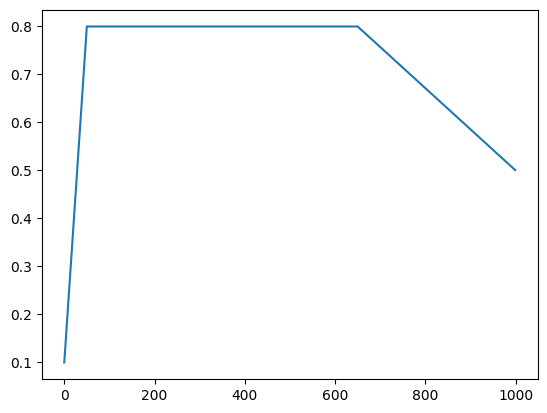

In [36]:
# @launchit.disable
steps_count = 1000
q = get_trapezoid_lr_anneal(0.1, 0.8, 0.5, steps_count)
lrs = []

for s in range(steps_count):
    lr = q(s)
    lrs.append(lr)

plt.plot(np.arange(steps_count), lrs);

### shark_fin

In [37]:
def get_shark_fin_lr_anneal(start_value, steps_count, warmup_steps_fraction=0.05):
    warmup_steps_count = int(steps_count * warmup_steps_fraction)

    def anneal_param(step):
        if step < warmup_steps_count:
            return start_value * (step / warmup_steps_count)
            
        progress = (step - warmup_steps_count) / max(1, steps_count - warmup_steps_count)
        return start_value * max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress))) # decays to 5% of max LR

    return anneal_param

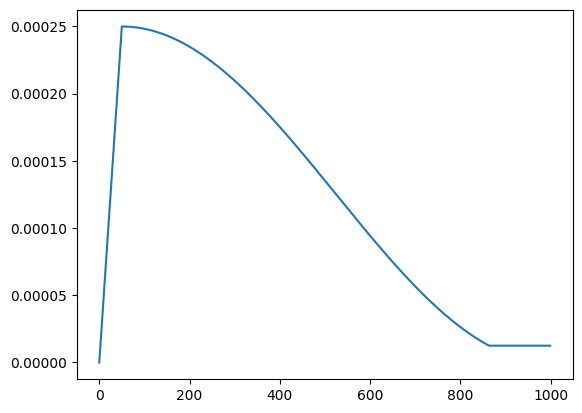

In [38]:
# @launchit.disable
steps_count = 1000
q = get_shark_fin_lr_anneal(0.00025, steps_count)
lrs = []

for s in range(steps_count):
    lr = q(s)
    lrs.append(lr)

plt.plot(np.arange(steps_count), lrs);

## Configure

In [39]:
# @launchit.disable
# @launchit.collect

# Training procedure params (PPO related) 
HP.ppo.global_steps_count = 10_000 # total number of steps 
HP.ppo.rollout_steps_count = 128 # how many steps to run in a single policy rolllout
HP.ppo.anneal_steps_count = 10_000 # anneal steps count for learn rate and entropy coeff

HP.ppo.epochs_count = 2 
HP.ppo.minibatches_count = 4

HP.ppo.gamma = 0.997 # return discount factor gamma
HP.ppo.gae_lambda = 0.95 # lambda for the general advantage estimation

HP.ppo.clip_coef = 0.1 # the surrogate clipping coefficient
HP.ppo.clip_vloss = True # Toggles whether or not to use a clipped loss for the value function, as per the paper
HP.ppo.init_ent_coef = 0.01 # initial coefficient of the entropy
HP.ppo.final_ent_coef = 0.01 # final coefficient of the entropy
HP.ppo.vf_coef = 0.5 # coefficient of the value function
HP.ppo.max_grad_norm = 0.5 # the maximum norm for the gradient clipping
HP.ppo.target_kl = None # e target KL divergence threshold
HP.ppo.norm_adv = True # Toggles advantages normalization
HP.ppo.reconstruction_coef = 0.0 # the coefficient of the observation reconstruction loss, if set to 0.0 the reconstruction loss is not used
HP.ppo.init_learn_rate = 0.00025
HP.ppo.final_learn_rate = 0
HP.ppo.learn_rate_annealer = 'shark_fin'
HP.ppo.optimizer = 'AdamW'
HP.ppo.is_parallel_teacher_forcing = False

# Video params
HP.video.capture_policy = 'every(1000000)' # video capture policy depending on steps

# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'env': {'ident': 'FrostbiteNoFrameskip-v4',
         'render_mode': 'rgb_array',
         'count': 32,
         'is_episodic_life_wrapper': False},
 'agent': {'layers_count': 3,
           'heads_count': 4,
           'd_model': 384,
           'sequence_length': 16,
           'positional_encoding': 'absolute'},
 'worker': {'count': 2},
 'video': {'capture_policy': 'every(1000000)'},
 'ppo': {'global_steps_count': 10000,
         'rollout_steps_count': 128,
         'anneal_steps_count': 10000,
         'minibatches_count': 4,
         'epochs_count': 2,
         'gamma': 0.997,
         'gae_lambda': 0.95,
         'clip_coef': 0.1,
         'clip_vloss': True,
         'init_ent_coef': 0.01,
         'final_ent_coef': 0.01,
         'vf_coef': 0.5,
         'max_grad_n

## Create

In [40]:
# @launchit.disable_2
capture_video_manager = CaptureVideoManager(HP.video.capture_policy)

ump = hp_parse_universal_module(HP.ppo.optimizer)
assert not ump.args
optimizer = getattr(torch.optim, ump.module_name)(LS.agent.parameters(), lr=HP.ppo.init_learn_rate, **ump.kwargs)

match HP.ppo.learn_rate_annealer:
    case 'linear': learn_rate_anneal = get_linear_anneal(HP.ppo.init_learn_rate, HP.ppo.final_learn_rate, HP.ppo.anneal_steps_count)
    case 'shark_fin': learn_rate_anneal = get_shark_fin_lr_anneal(HP.ppo.init_learn_rate, HP.ppo.anneal_steps_count)
    case _: assert False, f'Unsupported {HP.ppo.learn_rate_annealer=}'
        
ent_coef_anneal = get_linear_anneal(HP.ppo.init_ent_coef, HP.ppo.final_ent_coef, HP.ppo.anneal_steps_count)

In [41]:
# @launchit.disable_2
episode_stats_mafs = dict(l=RecursiveMovingAverageFilter(max_n=100), r=RecursiveMovingAverageFilter(max_n=100))
clip_fracs_af = RecursiveAverageFilter()

dataset = Dataset(
    envs_count=HP.env.count,
    observation_space_shape=LS.agent.params.observation_space_shape, 
    rollout_steps_count=HP.ppo.rollout_steps_count, 
    sequence_length=HP.agent.sequence_length, 
    batches_count=HP.ppo.minibatches_count,
    is_shuffled=False,
    is_ptf=HP.ppo.is_parallel_teacher_forcing,
    with_debug=False,
)

for name, v in dataset.shared_tensors.items():
    if v is not None:
        assert v.is_shared(), f'{name} is not shared'
        LOG(f'{name:>28}: {str(v.device):>6}, {str(v.dtype):>15}, {v.shape}')

envs_count_per_worker = HP.env.count // HP.worker.count
env_inds = torch.arange(HP.env.count)

# Init in serial, shows to be much faster than in parallel (GPU contention issues?)
for w_ind, w in enumerate(LS.workers): 
    lo_env_inds = w_ind * envs_count_per_worker
    hi_env_inds = lu.when((w_ind + 1) < HP.worker.count, (w_ind + 1) * envs_count_per_worker, None)
    w.init_rollout(env_inds[lo_env_inds:hi_env_inds], rollout_steps_count=HP.ppo.rollout_steps_count, prologue_size=dataset.prologue_size)
    w.drain_task_results()

                         obs: cuda:0,   torch.float32, torch.Size([32, 143, 3, 84, 84])
                  obs_pmasks: cuda:0,   torch.float32, torch.Size([32, 143, 16])
                     actions: cuda:0,     torch.int64, torch.Size([32, 143])
            action_log_probs: cuda:0,   torch.float32, torch.Size([32, 143])
                      values: cuda:0,   torch.float32, torch.Size([32, 143])
                  advantages: cuda:0,   torch.float32, torch.Size([32, 143])
                     returns: cuda:0,   torch.float32, torch.Size([32, 143])


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


## Train

In [43]:
# @launchit.disable_2
pbar = tqdm(total=HP.ppo.global_steps_count)
global_step = 0
global_step_inc = HP.env.count * HP.ppo.rollout_steps_count

while global_step < HP.ppo.global_steps_count:
    start_time = time.time()
    
    # ANNEAL STUFF
    learn_rate = learn_rate_anneal(global_step)
    for param_group in optimizer.param_groups: param_group["lr"] = learn_rate
    ent_coef = ent_coef_anneal(global_step)

    # ROLLOUT
    for w in LS.workers:
        w.rollout(dataset.shared_tensors)

    for w in LS.workers:
        tr = w.get_task_result().payload

        for episode_stats_item in tr['episode_stats']:
            episode_stats_mafs['l'](episode_stats_item['l'])
            episode_stats_mafs['r'](episode_stats_item['r'])

    # TRAINING
    for epoch in range(HP.ppo.epochs_count):
        for batch in dataset:
            av = LS.agent.get_action_and_value(
                X=batch.obs, 
                padding_masks=batch.obs_pmasks,
                actions=batch.actions, 
            )

            if HP.ppo.is_parallel_teacher_forcing:
                valid_inds = ~(batch.obs_pmasks.bool()).flatten()
                new_action_log_probs = av.action_log_probs.flatten()[valid_inds]
                new_prob_entropies = av.prob_entropies.flatten()[valid_inds]
                new_values = av.values.flatten()[valid_inds]
                b_advantages = batch.advantages.flatten()[valid_inds]
                b_action_log_probs = batch.action_log_probs.flatten()[valid_inds]
                b_returns = batch.returns.flatten()[valid_inds]
                b_values = batch.values.flatten()[valid_inds]
            else:
                assert torch.all(batch.obs_pmasks[:,-1] == 0)
                new_action_log_probs = av.action_log_probs
                new_prob_entropies = av.prob_entropies
                new_values = av.values
                b_advantages = batch.advantages
                b_action_log_probs = batch.action_log_probs
                b_returns = batch.returns
                b_values = batch.values

            # Policy loss
            if HP.ppo.norm_adv:
                b_advantages = (b_advantages - b_advantages.mean()) / (b_advantages.std() + 1e-8)

            logratio = new_action_log_probs - b_action_log_probs
            ratio = torch.exp(logratio)
            pgloss1 = -b_advantages * ratio
            pgloss2 = -b_advantages * torch.clamp(ratio, 1.0 - HP.ppo.clip_coef, 1.0 + HP.ppo.clip_coef)
            pg_loss = torch.max(pgloss1, pgloss2).mean()

            # Value loss
            v_loss_unclipped = (new_values - b_returns) ** 2 
            
            if HP.ppo.clip_vloss:
                v_loss_clipped = b_values + (new_values - b_values).clamp(min=-HP.ppo.clip_coef, max=HP.ppo.clip_coef)
                v_loss = torch.max(v_loss_unclipped, (v_loss_clipped - b_returns) ** 2).mean()
            else:
                v_loss = v_loss_unclipped.mean()

            # Entropy loss
            entropy_loss = new_prob_entropies.mean()

            # Combined losses
            loss = pg_loss - ent_coef * entropy_loss + HP.ppo.vf_coef * v_loss

            # Add reconstruction loss if used
            if HP.ppo.reconstruction_coef > 0.0:
                r_loss = F.binary_cross_entropy(LS.agent.reconstruct_observation(), batch.obs)
                loss += HP.ppo.reconstruction_coef * r_loss
            else:
                r_loss = torch.tensor(0) # create dummy one since r_loss is reported to tensorboard

            optimizer.zero_grad()
            loss.backward()
            grad_norm_groups = get_grad_norm_groups(LS.agent, ['cnn', 'transformer', 'actor', 'critic'])
            grad_norm = torch.nn.utils.clip_grad_norm_(LS.agent.parameters(), max_norm=HP.ppo.max_grad_norm)
            optimizer.step()

            with torch.no_grad():
                # calculate approx_kl http://joschu.net/blog/kl-approx.html
                approx_kl = ((ratio - 1) - logratio).mean()
                clip_fracs_af(((ratio - 1.0).abs() > HP.ppo.clip_coef).float().mean().item())

        if HP.ppo.target_kl is not None and approx_kl > HP.ppo.target_kl:
            break

    var_y = torch.var(dataset.returns)
    explained_var = lu.when(var_y == 0, np.nan, 1 - torch.var(dataset.returns - dataset.values) / var_y)

    # REPORT
    summary_writer.add_scalar('charts/sps', global_step_inc / (time.time() - start_time), global_step)
    summary_writer.add_scalar('charts/learning_rate', learn_rate, global_step)
    summary_writer.add_scalar('charts/entropy_coefficient', ent_coef, global_step)
    
    summary_writer.add_scalar('grad/grad_norm', grad_norm, global_step)

    for grad_norm_group_name, grad_norm_group_value in grad_norm_groups.items():
        summary_writer.add_scalar(f'grad/grad_norm_{grad_norm_group_name}', grad_norm_group_value, global_step)
    
    summary_writer.add_scalar('losses/loss', loss, global_step)
    summary_writer.add_scalar('losses/policy_loss', pg_loss, global_step)
    summary_writer.add_scalar('losses/value_loss', v_loss, global_step)
    summary_writer.add_scalar('losses/entropy_loss', entropy_loss, global_step)
    summary_writer.add_scalar('losses/reconstruction_loss', r_loss, global_step)
    summary_writer.add_scalar('losses/approx_kl', approx_kl, global_step)
    summary_writer.add_scalar('losses/clipfrac', clip_fracs_af.reset(), global_step)
    summary_writer.add_scalar('losses/explained_variance', explained_var, global_step)
    
    summary_writer.add_scalar('episode/l_mean', episode_stats_mafs['l'].v, global_step)
    summary_writer.add_scalar('episode/r_mean', episode_stats_mafs['r'].v, global_step)
    summary_writer.add_scalar('episode/value_mean', dataset.values.mean(), global_step)
    summary_writer.add_scalar('episode/advantage_mean', dataset.advantages.mean(), global_step)

    # VIDEO
    if capture_video_manager.should_capture_video(global_step) or (global_step + global_step_inc >= HP.ppo.global_steps_count):
        if capture_video_manager.is_busy():
            capture_video_manager.upload_captured_video(is_drain=True)
            
        capture_video_manager.schedule_capture_video(global_step)

    capture_video_manager.upload_captured_video()
    summary_writer.flush()

    # min is used to not overflow progress bar at the end (global_step could get > HP.ppo.global_step_size)
    pbar.update(min(global_step_inc, HP.ppo.global_steps_count - global_step)) 
    global_step += global_step_inc

capture_video_manager.upload_captured_video(is_drain=True)
summary_writer.flush()
pbar.close()

  0%|          | 0/10000 [00:00<?, ?it/s]

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


## Save

In [ ]:
# @launchit.disable_2
artifact_registry = LS.new_artifact_registry()
lc = HP.launch_component()

with io.BytesIO() as b:
    torch.save(LS.agent.state_dict(), b)
    artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='pt', asset_classifier='agent', replace=True)

with io.StringIO() as b:
    json.dump(dataclasses.asdict(LS.agent.params), b)
    artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='agent_params', replace=True)

# LaunchIt!

## TRAIN

In [23]:
# @launchit.disable
launchit_t0 = time.time()

In [24]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    artifact_registry = LS.new_artifact_registry(is_real=True)
    artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=component_version, expandvars=expandvars, collect_inds=[1], disable_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=3
Creating /home/misha/dev/mine/neurolab/17_rl/17e_ppo_tr_atari_mp_03-launch3.ipynb
Created launch notebook "/home/misha/dev/mine/neurolab/17_rl/17e_ppo_tr_atari_mp_03-launch3.ipynb"


## Optuna (model selection)

### Templates

In [ ]:
# @launchit.disable
# @launchit.collect_3
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    
    match study_serial:
        case 1:
            HP = Hyperparameters()
            HP.random_seed = 42
            assert False
        case _:
            assert False, f'Unsupported {study_serial=}'            

### Unleash

In [ ]:
# @launchit.disable
def get_optimize_directions(lg):
    match lg:
        case LaunchGoal.TRAIN_MODEL:
            return ['minimize']
        case _:
            assert False, f'Unsupported {lg=}'

lg = LaunchGoal.TRAIN_MODEL
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=lg.value,
)
study_serial = 1
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_{study_serial}'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[],
    run_path=CONFIG.run_path,
    study_serial=study_serial,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(lg),
)
rop_tasks = [rop_task] * 1
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")